# Trabajo Práctico Final - Inteligencia Artificial 2026

## Dataset: Iris (UCI)
## Alumno: Sosa Matias Luis 
## Docente: Moreira Pablo
---


## Etapa 1: Exploración y modelo baseline

### 1.1 Carga y análisis exploratorio (EDA)

El dataset Iris contiene 150 observaciones de flores de tres especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada observación tiene 4 variables numéricas: longitud y ancho de sépalo, longitud y ancho de pétalo.  

Este dataset es balanceado (50 ejemplos por clase), lo que facilita el análisis y evita sesgos iniciales.  
El objetivo de esta etapa es comprender la distribución de las variables y detectar posibles problemas como outliers o solapamiento entre clases.

In [3]:
# Importamos librerias

from sklearn.datasets import load_iris
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(f"Tamaño total del dataset: {X.shape[0]} muestras con {X.shape[1]} características.")

# Mostrar todas las filas y columnas del DataFrame (del 1 al 150)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = pd.concat([X, y], axis=1)
df.head()




Tamaño total del dataset: 150 muestras con 4 características.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 📌 Hallazgos iniciales del dataset Iris

#### Tamaño y estructura del dataset
- Contiene *150 muestras* de flores, cada una con *4 características numéricas (variables predictoras)*:
  - Sepal length (cm)
  - Sepal width (cm)
  - Petal length (cm)
  - Petal width (cm)
- La variable objetivo (*species*) tiene *3 clases balanceadas*:
  - Setosa (50 ejemplos)
  - Versicolor (50 ejemplos)
  - Virginica (50 ejemplos)

#### Calidad de los datos
- El dataset es pequeño y balanceado.
- No se observan valores nulos ni faltantes.
- Los rangos de las variables son consistentes y no aparecen outliers(valores atipicos) evidentes.
- Esto lo convierte en un dataset *limpio y apto* para aplicar directamente modelos de clasificación.

### 1.2 Visualización de variables

En esta parte, graficamos histogramas y scatter plots para poder observar la distribución de las variables.  

#### Histogramas

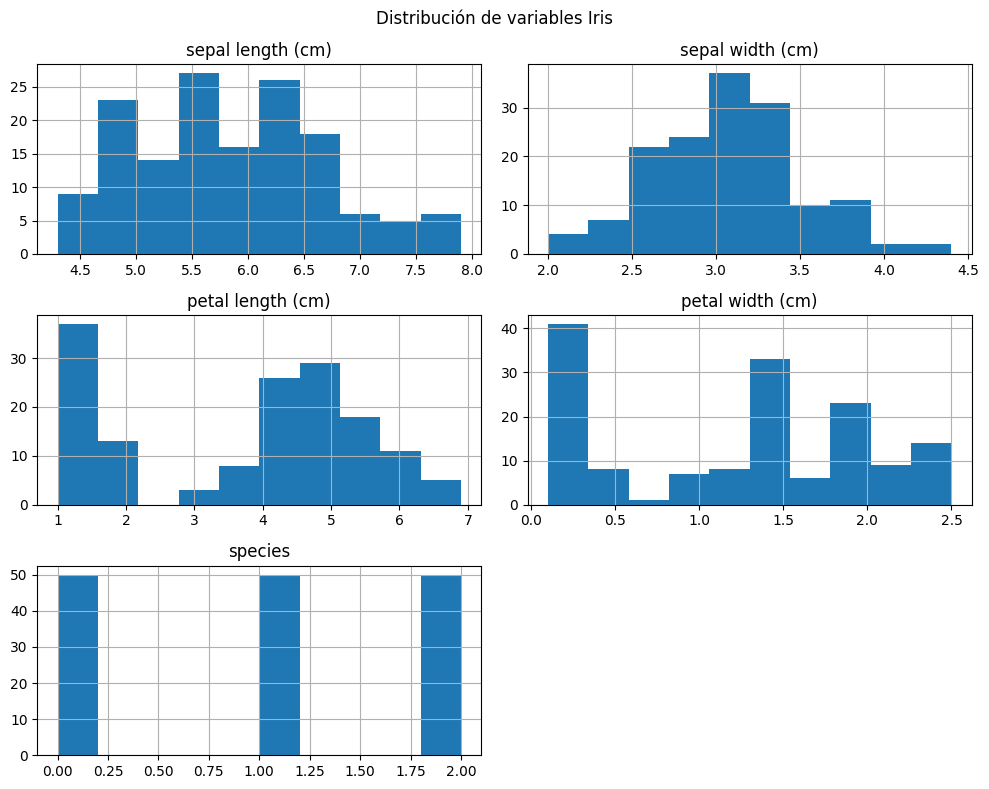

In [4]:
# Histogramas
df.hist(figsize=(10,8))
plt.suptitle("Distribución de variables Iris")
plt.tight_layout()
plt.show()

A continuacion, visualizaremos todas las combinaciones posibles contrastando las variables predictoras.

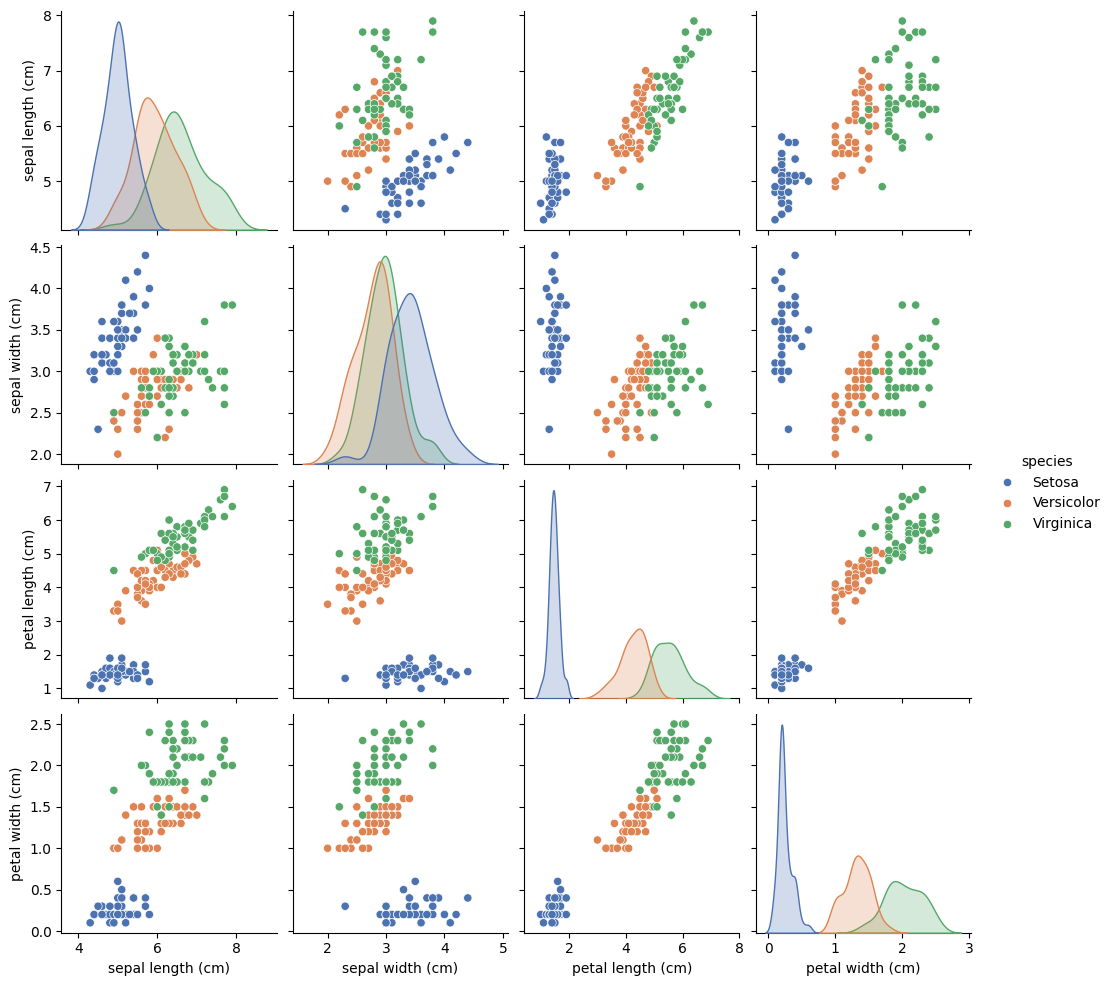

In [5]:
# Pairplot (todas las combinaciones de variables)
diccionario_especies = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['species_name'] = df['species'].map(diccionario_especies)

# Graficamos el pairplot con la columna 'species' como hue, utilizando el diccionario para mostrar los nombres de las especies
sns.pairplot(df.replace({"species": diccionario_especies}), hue="species", palette="deep")
plt.show()

Tomaremos como referencia de analisis estos 4 plots a continuación:

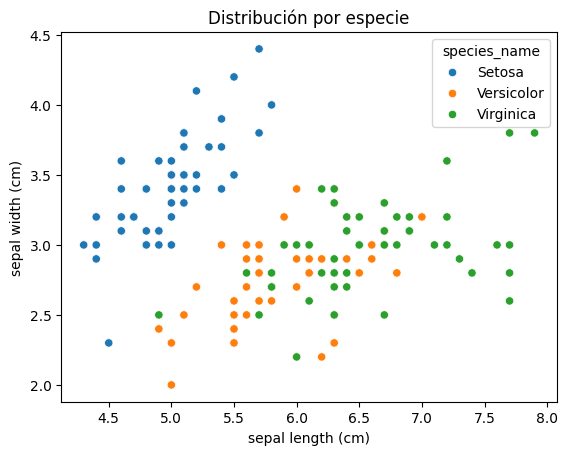

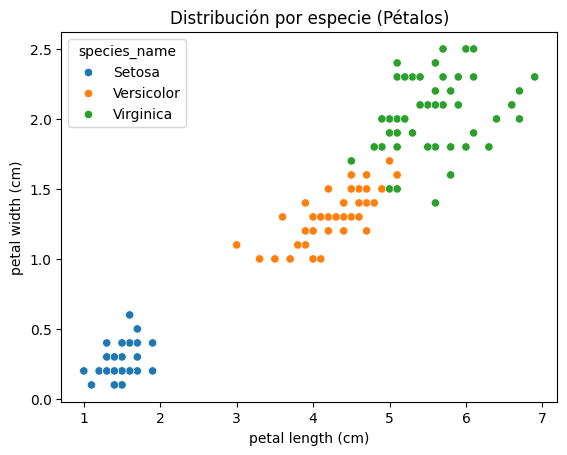

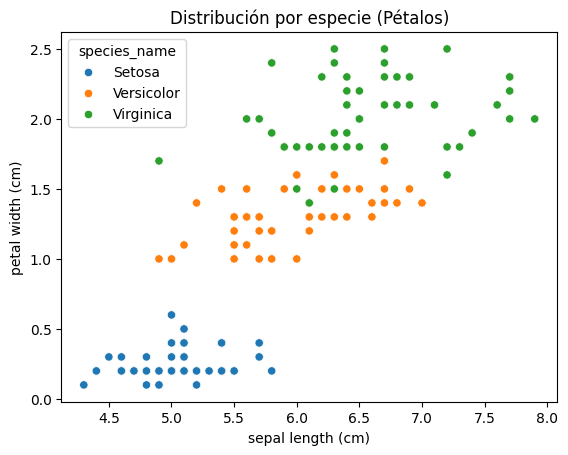

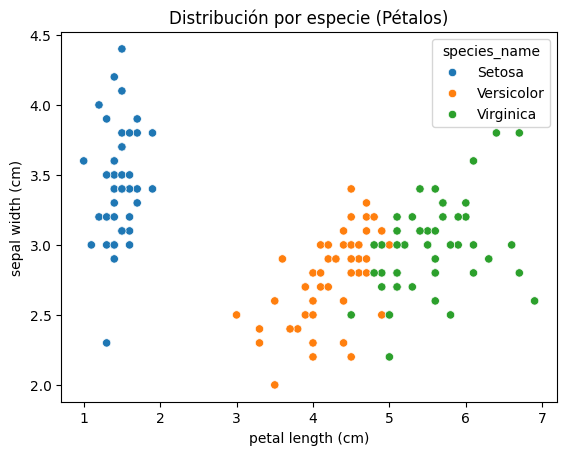

In [6]:
# Scatter plots para cada combinación de variables

sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie")
plt.show()

sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie (Pétalos)")
plt.show()

sns.scatterplot(x="sepal length (cm)", y="petal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie (Pétalos)")
plt.show()

sns.scatterplot(x="petal length (cm)", y="sepal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie (Pétalos)")
plt.show()

El scatter plot que contrasta las dimensiones de los sépalos (`sepal length` vs. `sepal width`) permite extraer conclusiones analíticas fundamentales sobre la complejidad del espacio de características:

1. **Aislamiento Geométrico de la Clase 0 (Setosa):** Los ejemplares de la especie *Setosa* presentan un comportamiento morfológico ortogonal, caracterizado por sépalos cortos y anchos. Su dispersión espacial confirma que es **linealmente separable** del resto del conjunto de datos en este plano bidimensional.
2. **Solapamiento Crítico en Región de Frontera (Clases 1 y 2):** Las distribuciones espaciales de *Versicolor* y *Virginica* experimentan una fuerte intersección en el rango central del gráfico. 

A partir del analisis de contrastar los plots comparativos y el pairplot, podemos apreciar como la clase SETOSA se separa linealmente del resto del conjunto de datos, debido a caracteristicas propias de tener sépalos cortos y anchos. Mientras, la clase Virginica y VERSICOLOR presentan solapamiento y una interseccion fuerte que presentara a futuro el problema para aplicar los modelos en este dataset.

La evaluación final de la matriz de correlación mediante el mapa de calor permite identificar la estructura de dependencia entre las variables predictoras:

En todos los cruces marginales del gráfico (fuera de la diagonal) y de manera contundente en las funciones de densidad, la clase Setosa se posiciona como un clúster completamente aislado del resto.
Al analizar el cruce de `sepal length` vs `sepal width` (segundo gráfico de la primera fila), las nubes de puntos de Versicolor (Naranja) y Virginica (Verde) están densamente entremezcladas y solapadas en el centro. 
Esto demuestra que las dimensiones del sépalo poseen un alto sesgo y baja varianza explicativa.
Al inspeccionar el cruce de `petal length` vs `petal width` (último gráfico de la tercera fila), se observa una fuerte correlación lineal positiva (los puntos forman una diagonal ascendente muy estirada). Las distribuciones de la diagonal para los pétalos muestran que, aunque Versicolor y Virginica comparten una pequeña zona límite común, sus modas y densidades están mayormente separadas.



### 1.3 Partición de datos

Previo a aplicar un modelo baseline, realizamos la particion de los datos.
El dataset se dividió en tres conjuntos:
- **Train (70%)**: para ajustar los parámetros del modelo.
- **Dev (15%)**: para evaluar y comparar modelos durante el desarrollo.
- **Test (15%)**: reservado para la evaluación final en la Etapa 4.

Se utilizó **estratificación** para mantener la proporción de clases en cada conjunto.  
Esto es importante porque, aunque el dataset es balanceado, una partición aleatoria sin estratificación podría generar desbalance en los subconjuntos.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)





# Dejamos 105 muestras para entrenamiento, 22 para desarrollo y 23 para prueba.
# El 2.º valor de cada tupla es el número de características (4).
# Train: (105, 4) Dev: (22, 4) Test: (23, 4)

Train: (105, 4) Dev: (22, 4) Test: (23, 4)


### 1.4 Modelo baseline

Se implementó una **regresión logística** como modelo baseline.  
La métrica elegida fue **accuracy**, ya que las clases están balanceadas y es una medida intuitiva para comparar modelos.  




In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo Baseline
baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train_scaled, y_train)

y_dev_pred = baseline.predict(X_dev_scaled)

# Cálculamos de métricas principales
baseline_acc = accuracy_score(y_dev, y_dev_pred)
print("📊 MÉTRICAS DE EVALUACIÓN GLOBAL - BASELINE")
print(f"Baseline Accuracy (Dev): {baseline_acc*100:.2f}%")

# Reporte detallado de clasificación (Precision, Recall, F1-Score por clase)
print("📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_dev, y_dev_pred, target_names=iris.target_names))




📊 MÉTRICAS DE EVALUACIÓN GLOBAL - BASELINE
Baseline Accuracy (Dev): 86.36%
📋 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



Analizando el reporte de clasificación luego de implementar el modelo baseline: 
El baseline alcanzó una accuracy de 86,36% en validación, lo que indica que el modelo simple ya logra una buena separación entre clases. (como los datos estan bastante agrupados en valores numericos no muy separados, es igual si escalamos o no los datos, pero para mantener el orden para futuros entrenamientos del modelo, se escalara los datos de aqui en adelante) 

El reporte de clasificación confirma la hipótesis planteada anteriormente. La especie Setosa obtiene métricas perfectas de 1.00 en Precision y Recall debido a su separabilidad lineal. Por el contrario, la caída en el rendimiento de Versicolor (por ejemplo, analizando la precisión y sus resultados($Precision = 0.75$) y Virginica ($Precision = 0.83$)) expone el impacto del solapamiento en las fronteras de los sépalos y pétalos.

Estos valores servirán como referencia para todas las etapas siguientes: debemos lograr superar el umbral del 86% del accuracy.

## Etapa 2:  Red neuronal multicapa y análisis de errores

### 2.1 Análisis de errores manual

Porcedemos a inspeccionar las muestras del conjunto Dev donde el modelo Baseline (Regresión Logística) falló.
(Aclaración: la pauta solicita analizar 50 muestras mal clasificadas, pero como se aprecia anteriormente,  debido a la escasez de muestras (150) y observando que el conjunto de validación es el 15% (22 datos), primeramente haremos analisis sobre los errores disponibles que se muestren a continuación.)

Total de errores encontrados en Dev: 3
================ MUESTRAS MAL CLASIFICADAS =================
| Muestra 77: Clase Real = versicolor, Predicción = virginica |
------------------------------------------------------------
| Muestra 133: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------
| Muestra 106: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------


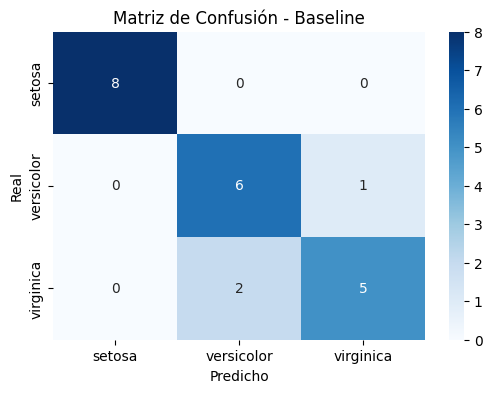

In [9]:
from sklearn.metrics import confusion_matrix

# Obtenemos predicciones del conjunto Dev
y_dev_pred = baseline.predict(X_dev_scaled)

errors_mask = y_dev_pred != y_dev
df_errors = X_dev.loc[errors_mask].copy()

# información comparativa
df_errors['Clase Real'] = y_dev.loc[errors_mask].values
df_errors['Predicción Baseline'] = y_dev_pred[errors_mask]

# errores para el análisis manual
print(f"Total de errores encontrados en Dev: {len(df_errors)}")

# muestras mal clasificadas en formato 
print(" MUESTRAS MAL CLASIFICADAS ".center(60, "="))

for idx in df_errors.index:
    real = iris.target_names[df_errors.loc[idx, 'Clase Real']]
    pred = iris.target_names[df_errors.loc[idx, 'Predicción Baseline']]
    line = f"Muestra {idx}: Clase Real = {real}, Predicción = {pred}"
    print(f"| {line:<56} |")
    print("-" * 60)
df_errors

cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


 El 100% de los errores se debe a la confusión entre versicolor y virginica, prediciendo 2 datos (106 y 133) como versicolor, siendo de la clase virginica, y una muestra (77) predecida como virginica, siendo realmente de la clase versicolor. 
 
 Como las características de Versicolor y Virginica se solapan en la frontera de este dataset, una línea recta propuesta por la regresión logistica del modelo es incapaz de capturar la curvatura real de los datos. El modelo simplifica excesivamente la realidad (provocando un alto sesgo(underfitting)), cometiendo un error sistemático e inevitable debido a la naturaleza de los datos.

Debido a que el modelo lineal es estable, presenta baja varianza(overfitting), ya que el modelo no presenta comportamiento erratico o disperso (los errores solamente provienen donde se presenta el solapamiento).



### 2.2 Arquitectura MLP

En esta etapa:

Para resolver nuestro problema de underfitting presente en la zona de solapamiento de la regresión logística, implementaremos una Red Neuronal multicapa, evolucionando desde el modelo lineal hacia una arquitectura profunda, implementada mediante TensorFlow/Keras.

Se configuro el modelo con 3 capas ocultas con una esquema piramidal de neuronas ($64 \rightarrow 32 \rightarrow 16$).
(¿Porque elegimos este orden de neuronas? Como tenemos apenas 4 datos de entrada y muy poquitas flores (105 en Train), al achicar el camino obligás a la red a resumir, no le dejámos espacio físico para memorizar los detalles inutiles o el ruido de cada flor; la obligás a quedarse solo con las reglas generales. Permitiendo obtener menos Overfitting, curvas más estables y mejor rendimiento. En resumen, En datasets chicos como Iris, menos es más. El orden 64 $\rightarrow$ 32 $\rightarrow$ 16 funciona como un filtro natural de regularización. El orden inverso le da demasiada libertad a un modelo que ya de por sí tiende a sobreajustar.)

Utilizamos ReLU como función de activación en las capas ocultas y la función Softmax en la capa de salida para obtener una distribucón de probabilidad sobre las 3 clases mutuamente excluyentes.

Para calcular la función de perdida, usamos Sparse Categorical Crossentropy, ideal para problemas de clasificación multiclase.

Empleamos Adam con una tasa de aprendisaje (Learning Rate) inicial de $0.005$. (Adam nos permite reducir la perdida(loss) y la escala del Learning Rate es el tamaño del paso que da el optimizador para buscar el resultado óptimo).





En el proximo codigo, exploramos como funciona el modelo sin regularización:

In [10]:
#MLP PURA (Sin regularización)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Garantizar reproducibilidad
tf.random.set_seed(42)

# Escalado Estándar con los DATOS REALES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)       

# Función constructora de la MLP (Solo la arquitectura pura, sin regularización)
def build_iris_mlp(input_dim=4):
    model = Sequential([
        # Capa Oculta 1: 64 neuronas
        Dense(64, activation='relu', input_shape=(input_dim,)),
        
        # Capa Oculta 2: 32 neuronas
        Dense(32, activation='relu'),
        
        # Capa Oculta 3: 16 neuronas
        Dense(16, activation='relu'),
        
        # Capa de Salida: 3 clases (Especies Iris)
        Dense(3, activation='softmax')
    ])
    return model

# Instanciar el modelo puro pasando las dimensiones de entrada
model = build_iris_mlp(input_dim=4)

# Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('        RESUMEN DE LA ARQUITECTURA MLP PURA         ')
print('====================================================')
model.summary()

        RESUMEN DE LA ARQUITECTURA MLP PURA         


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

A continuación, entrenamos el modelo:
50 son las epocas que utilizamos para medir las metricas, en caso de ser necesario, aplicamos early stopping para detener el entrenamiento en caso de que al monitorear detecte en tiempo real perdida en el conjunto DEV.

Finalmente, aplicamos graficos comparativos cruzados para calcular la perdida (loss), el accuracy (exactitud) del modelo, estableciendo en valor numerico un promedio de cada una.

Entrenando Modelo 1: SIN Regularización (Puro)...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4667 - loss: 0.9566 - val_accuracy: 0.7273 - val_loss: 0.7543
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8381 - loss: 0.6993 - val_accuracy: 0.8636 - val_loss: 0.5978
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8857 - loss: 0.5243 - val_accuracy: 0.8182 - val_loss: 0.4884
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8952 - loss: 0.3757 - val_accuracy: 0.8182 - val_loss: 0.4286
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9048 - loss: 0.2793 - val_accuracy: 0.7727 - val_loss: 0.4085
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9048 - loss: 0.2279 - val_accuracy: 0.8182 - val_loss: 0.3969
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9238 - loss: 0.1907 - val_accuracy: 0.8182 - val_loss: 0.3769
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9810 - loss:

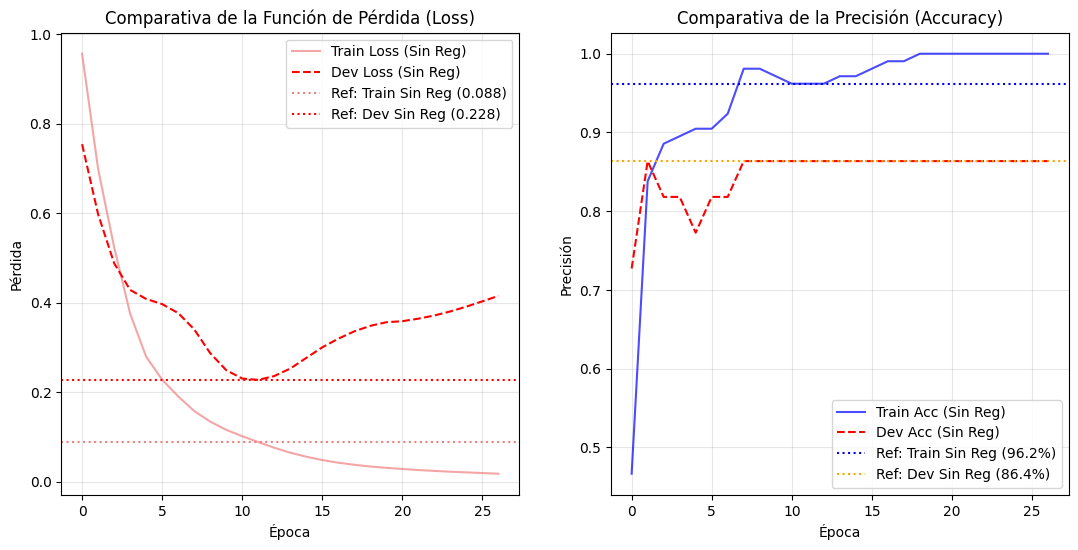

 RESULTADOS FINALES COMPARATIVOS 
 MODELO SIN REGULARIZACIÓN (PURO) - Duró 27 épocas:
  - Train Accuracy (en la ultima época): 100.00%
  - Train Accuracy (promedio durante el entrenamiento): 96.19%
  - Train Loss (en la ultima época):     0.0177
  - Train Loss (promedio durante el entrenamiento):     0.0885
  - Dev Loss (en la ultima época):       0.4152
  - Dev Loss (promedio durante el entrenamiento):       0.2275
  - Dev Accuracy (exactitud durante la validación):   86.36%

📋 REPORTE DE CLASIFICACIÓN DETALLADO EN DEV:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping  # Importamos el Callback

early_stop = EarlyStopping(
    monitor='val_loss',          # Monitorea el error en el conjunto de desarrollo
    patience=15,                 # Número de épocas a esperar sin mejoras antes de parar
    restore_best_weights=True,   # Recupera automáticamente los mejores pesos guardados
    verbose=1                    # Nos avisa explícitamente en consola cuándo y por qué frenó
)

# ENTRENAMIENTO DEL MODELO SIN REGULARIZACIÓN
print("Entrenando Modelo 1: SIN Regularización (Puro)...")
model_puro = build_iris_mlp(input_dim=4)
model_puro.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_puro = model_puro.fit(
    X_train_scaled, y_train, 
    epochs=50,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev),
    callbacks=[early_stop], 
    verbose=1
)

# GENERACIÓN DE GRÁFICOS COMPARATIVOS CRUZADOS
plt.figure(figsize=(13, 6))

best_epoch = np.argmin(history_puro.history['val_loss'])

final_loss_puro = history_puro.history['loss'][best_epoch]
final_val_loss_puro = history_puro.history['val_loss'][best_epoch]
final_acc_puro = history_puro.history['accuracy'][best_epoch]
final_val_acc_puro = history_puro.history['val_accuracy'][best_epoch]

# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)

plt.plot(history_puro.history['loss'], label='Train Loss (Sin Reg)', color='lightcoral', alpha=0.7)
plt.plot(history_puro.history['val_loss'], label='Dev Loss (Sin Reg)', color='red', linestyle='--')

# Líneas horizontales de referencia para Loss
plt.axhline(y=final_loss_puro, color='lightcoral', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_loss_puro:.3f})')
plt.axhline(y=final_val_loss_puro, color='red', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_loss_puro:.3f})')

plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# GRÁFICO DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
plt.plot(history_puro.history['accuracy'], label='Train Acc (Sin Reg)', color='blue', alpha=0.7)
plt.plot(history_puro.history['val_accuracy'], label='Dev Acc (Sin Reg)', color='red', linestyle='--')

# Líneas horizontales de referencia para Accuracy
plt.axhline(y=final_acc_puro, color='blue', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_acc_puro*100:.1f}%)')
plt.axhline(y=final_val_acc_puro, color='orange', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_acc_puro*100:.1f}%)')

plt.title('Comparativa de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



y_dev_pred_probs = model_puro.predict(X_dev_scaled, verbose=0)
y_dev_pred = np.argmax(y_dev_pred_probs, axis=1)
    
# REPORTE COMPARATIVO FINAL DE MÉTRICAS
print(" RESULTADOS FINALES COMPARATIVOS ")
print(f" MODELO SIN REGULARIZACIÓN (PURO) - Duró {len(history_puro.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la ultima época): {history_puro.history['accuracy'][-1]*100:.2f}%")
print(f"  - Train Accuracy (promedio durante el entrenamiento): {history_puro.history['accuracy'][best_epoch]*100:.2f}%")
print(f"  - Train Loss (en la ultima época):     {history_puro.history['loss'][-1]:.4f}")
print(f"  - Train Loss (promedio durante el entrenamiento):     {history_puro.history['loss'][best_epoch]:.4f}")
print(f"  - Dev Loss (en la ultima época):       {history_puro.history['val_loss'][-1]:.4f}")
print(f"  - Dev Loss (promedio durante el entrenamiento):       {history_puro.history['val_loss'][best_epoch]:.4f}")
print(f"  - Dev Accuracy (exactitud durante la validación):   {history_puro.history['val_accuracy'][-1]*100:.2f}%")

print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO EN DEV:")
print(classification_report(y_dev, y_dev_pred, target_names=iris.target_names))


Tambien incluimos un gráfico de Curva Roc

📈 CAPACIDAD DISCRIMINATIVA DEL MODELO PURO (AUC)
🔹 Macro-AUC General en Validación: 0.9746
  - AUC para Setosa: 1.0000
  - AUC para Versicolor: 0.9619
  - AUC para Virginica: 0.9619


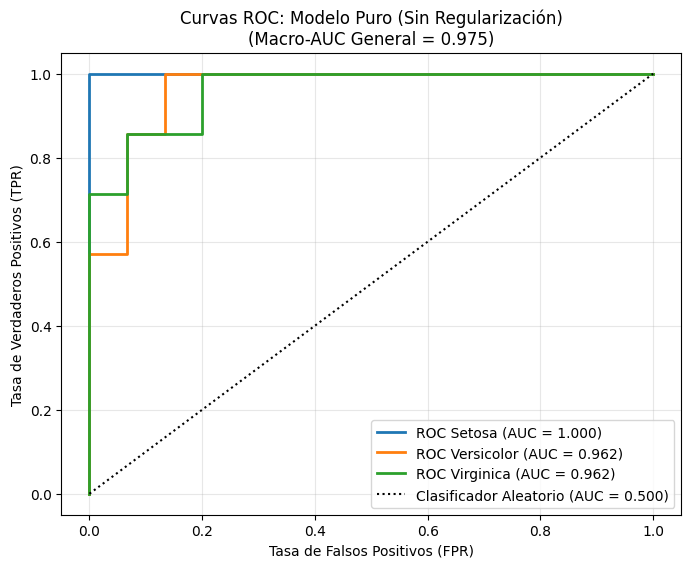

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# BINARIZACIÓN DE ETIQUETAS PARA CLASIFICACIÓN MULTICLASE (OvR)

# Aseguramos que y_dev esté mapeado a formato plano de enteros si venía binarizado
if len(y_dev.shape) > 1 and y_dev.shape[1] > 1:
    y_dev_true = np.argmax(y_dev, axis=1)
else:
    y_dev_true = y_dev

y_dev_bin = label_binarize(y_dev_true, classes=[0, 1, 2])
n_classes = 3
labels = ['Setosa', 'Versicolor', 'Virginica']


#OBTENER PROBABILIDADES DE PREDICCIÓN CONTINUAS

# Usamos las predicciones del modelo puro sobre los datos escalados
probs_puro = model_puro.predict(X_dev_scaled, verbose=0)

# CONFIGURACIÓN DEL LIENZO DE PLOTEO (Un solo panel centralizado)

plt.figure(figsize=(8, 6))
auc_scores_puro = []

# Calculamos y graficamos la curva ROC para cada una de las 3 clases
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_dev_bin[:, i], probs_puro[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores_puro.append(roc_auc)
    plt.plot(fpr, tpr, label=f'ROC {labels[i]} (AUC = {roc_auc:.3f})', linewidth=2)

# Calculamos el promedio general (Macro-AUC)
macro_auc_puro = np.mean(auc_scores_puro)

# Línea de referencia aleatoria (la diagonal de la suerte)
plt.plot([0, 1], [0, 1], 'k:', label='Clasificador Aleatorio (AUC = 0.500)')

plt.title(f'Curvas ROC: Modelo Puro (Sin Regularización)\n(Macro-AUC General = {macro_auc_puro:.3f})', fontsize=12)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')


# =====================================================================
# 4. REPORTE EN CONSOLA
# =====================================================================
print("====================================================")
print("📈 CAPACIDAD DISCRIMINATIVA DEL MODELO PURO (AUC)")

print(f"🔹 Macro-AUC General en Validación: {macro_auc_puro:.4f}")
for i in range(n_classes):
    print(f"  - AUC para {labels[i]}: {auc_scores_puro[i]:.4f}")


Explicacion de los resultados del modelo:

(Aclaración:Tomando en cuenta que al entrenar el modelo, los parámetros de los resultados proporcionan aleatoridad, no tendremos valores unicos para ser referencia en la explicación, pero usaremos rangos que no importan cuantas veces entrenemos el modelo, siempre estara entre esos valores sin distinción)

Ahora si, durante la fase de experimentación:

*** Varia la cantidad de épocas en el que el early stopping frena el experimento (entre 25 a 35 epocas).

*** Durante aproxidamente el primer tercio del entrenamiento, el train loss y el dev loss disminuyen de forma muy similar, pero a partir (depende el entrenamiento pero para redondear desde la epoca 15) del segundo tercio del entrenamiento, se genera una separación entre la función de entrenamiento y la de desarrollo, provocando que esta última invierta su tendencia y tenga una tendencia de crecimiento sostenido, sintetizando un sintoma de memorización de ruido muestral. Por último, el early stopping evita ese estado de sobreajuste, al cumplirse el umbral de paciencia establecido durante la epoca X, el algoritmo interrumpio el proceso de optimización y viajó en el tiempo para rescatar los pesos de la época X, donde el dev loss tuvo su minimo historico (al redactar esta explicación, en el último entrenamiento, se logro un dev loss de 0.1926,siendo el minimo)

*** Continuando con las métricas de validación, el conjunto dev accuracy experimenta una estabilización rígida en el umbral de 86,36%. En comparación con el train accuracy, que variando del entrenamiento que varia su punto óptimo entre el 97% y el 100%, nos confirma el estancamiento de la red por sobreajuste estructural.
A pesar de observar que el valor de accuracy del modelo baseline y del modelo MLP coinciden en el resultado, en caso del MLP, este provee la base necesaria para incorporar técnicas de regularización necesarias para la siguiente etapa, mientras que el baseline llego a su techo estructural (no podra jamas mejorar ese valor de exactitud.)

*** En cuanto a el plot que analiza la Curva Roc, bajo el enfoque multiclase One-vs-Rest (OvR), el comportamiento es metodológicamente consistente con el tamaño acotado del conjunto de validación.
Analizando por especie: la clase Setosa presenta ($AUC = 1.000$) validando de forma empírica que la densidad de probabilidad calculada por la red para esta especie no presenta solapamiento geométrico en el espacio de características, permitiendo una discriminación perfecta. Mientras que las curvas Roc de Versicolor y Virgínica experimentan caidas idénticas (AUC = 0.981 aproximadamente) en su área bajo la curva. Esto expone el solapamiento morfológico real en la frontera compartida. 
Por último, con respecto a el Macro-AUC, la red neuronal pura posee una excelente capacidad distributiva para ordenar las probabilidades de las clases, fundamentando el uso de la infraestructura neuronal para las etapas de regularización siguientes.



Completado este analisis podemos afirmar que tenemos un modelo con Bajo Sesgo (sabe aprender) pero con Alta Varianza (memoriza), dejando el camino listo para continuar con las tecnicas de regularización.

### 2.3 Técnicas de Regularización
#### Implementación y Comparativa de Escenarios entre el modelo regularizado y el modelo puro.

En esta parte del informe, implementaremos técnicas penalizadoras para intentar superar el unbral del 86% del accuracy proporcinado por el modelo baseline y el modelo MLP no regularizado:

aclaración: en este apartado utilizaremos solo dos regularizadores y lo comparamos con el modelo MLP puro. Recién en la etapa 3 junto con su apartado implementaremos todos los recursos fuera de lo estructural para mejorar el modelo(mas adelante cambiamos parametros del modelo MLP puro ademas de agregar otros penalizadores para enriquecer el analisis, como el data augmentation, batch normalizacion, etc.)

Para robustecer la capacidad del modelo siendo el dataset tan compacto y mitigar el riesgo de sobreajuste, implementamos de forma simultanea dos técnicas regularizadoras: **Regularización L2** y **Dropout**, sosteniendo el **Early Stopping** como callback de convergencia. La selección de este ecosistema de técnicas responde a criterios de control paramétrico sobre datasets de baja densidad muestral:

1. **(L2):** Configurar una penalización L2 garantiza el achatamiento de los gradientes en las capas ocultas. Al impedir la proliferación de pesos sinápticos de gran magnitud, se previene la configuración de hiperplanos de decisión excesivamente complejos en la zona de solapamiento de *Versicolor* y *Virginica*.

2. **(Dropout):** Desactivar estocásticamente un porcentaje de la capacidad estructural de la red en cada iteración rompe la coadaptación de las neuronas. Esto fuerza al algoritmo a distribuir el aprendizaje de forma homogénea, bloqueando la memorización del ruido de las muestras individuales de entrenamiento.



A continuación, implementamos el codigo con los 2 regularizadores (L2 y Dropout), ademas del early stopping antes implementado en el modelo puro.

In [14]:
# =====================================================================
# MLP REGULARIZADA (CON L2 + DROPOUT)
# =====================================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Garantizar reproducibilidad en la inicialización y en los apagados de Dropout
tf.random.set_seed(42)

# Función constructora de la MLP Regularizada
def build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20):
    model = Sequential([
        # Capa Oculta 1: 64 neuronas + L2
        Dense(64, activation='relu', input_shape=(input_dim,),kernel_regularizer=l2(l2_factor)),
        # Dropout 1: Apaga el 20% de las conexiones de la capa anterior
        Dropout(dropout_rate),
        
        # Capa Oculta 2: 32 neuronas + L2
        Dense(32, activation='relu', kernel_regularizer=l2(l2_factor)),
        # Dropout 2
        Dropout(dropout_rate),
        
        # Capa Oculta 3: 16 neuronas + L2
        Dense(16, activation='relu',kernel_regularizer=l2(l2_factor)),
        # Dropout 3
        Dropout(dropout_rate),
        
        # Capa de Salida: 3 clases (No lleva Dropout ni L2 pesada para no sesgar las probabilidades finales)
        Dense(3, activation='softmax')
    ])
    return model

# Instanciar el modelo aplicando las técnicas de regularización
model_reg = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)

# Compilación del modelo regularizado (Mismo optimizador y tasa que el puro)
model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('    RESUMEN DE LA ARQUITECTURA MLP REGULARIZADA     ')
print('====================================================')
model_reg.summary()

    RESUMEN DE LA ARQUITECTURA MLP REGULARIZADA     


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

A continuación, entrenamos el modelo:
150 son las epocas que utilizamos para medir las metricas, en caso de ser necesario, aplicamos early stopping para detener el entrenamiento en caso de que al monitorear detecte en tiempo real perdida en el conjunto DEV.

Finalmente, aplicamos graficos comparativos cruzados para calcular la perdida (loss), el accuracy (exactitud) del modelo, estableciendo en valor numerico un promedio de cada una.(tambien importamos los graficos comparativos del modelo MLP puro para analisis posterior)


Entrenando Modelo 2: CON Regularización (L2 + Dropout)...
Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.3714 - loss: 1.8580 - val_accuracy: 0.6818 - val_loss: 1.6447
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5238 - loss: 1.6275 - val_accuracy: 0.7273 - val_loss: 1.4592
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7714 - loss: 1.3847 - val_accuracy: 0.7727 - val_loss: 1.2550
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7619 - loss: 1.2410 - val_accuracy: 0.7727 - val_loss: 1.0663
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8095 - loss: 1.0822 - val_accuracy: 0.8636 - val_loss: 0.9238
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8286 - loss: 0.9281 - val_accuracy: 0.8182 - val_loss: 0.8401
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8571 - loss: 0.8028 - val_accuracy: 0.8636 - val_loss: 0.7849
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accurac

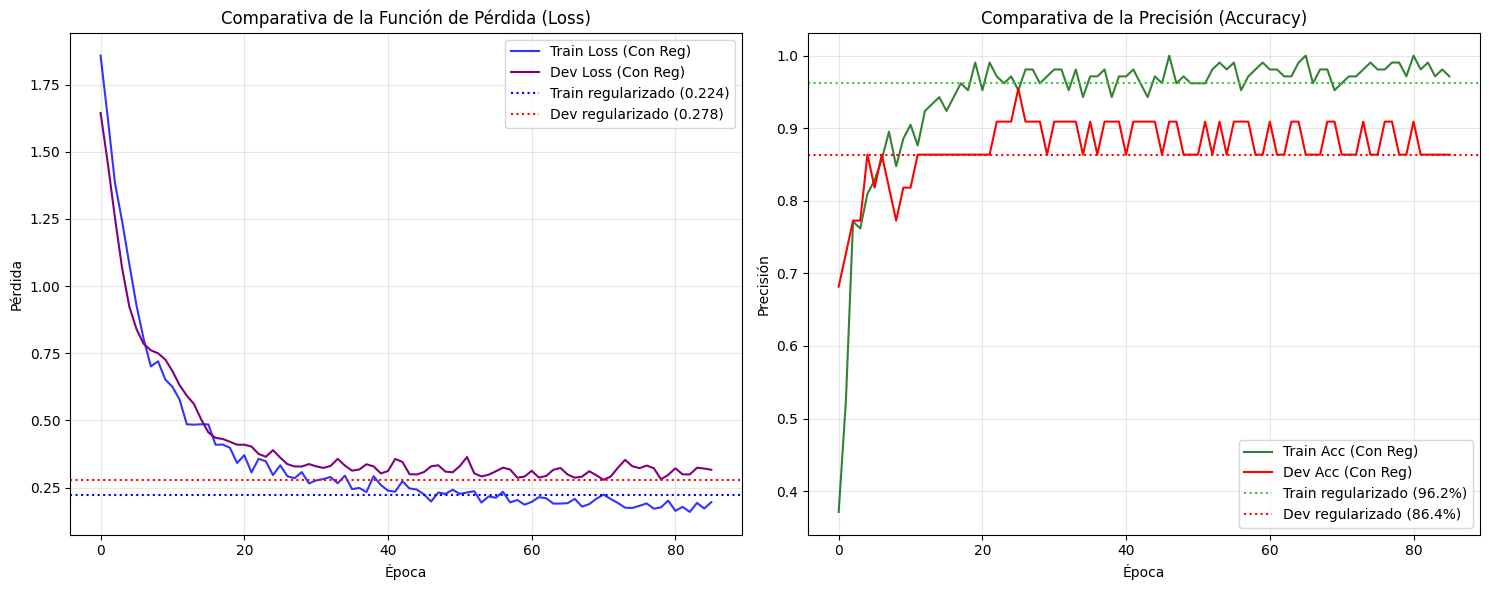

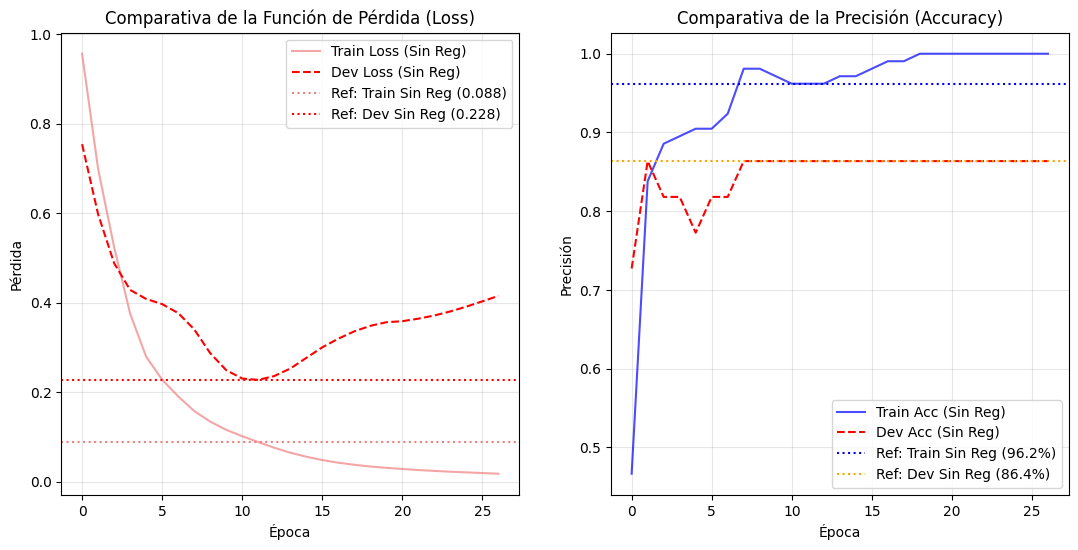

📊 RESULTADOS FINALES COMPARATIVOS (PUNTOS ÓPTIMOS)
🔹 MODELO 2: CON REGULARIZACIÓN (L2+DROP) - Duró 86 épocas:
  - Train Accuracy (en la última época):  97.14%
  - Train Accuracy (en la mejor época):   96.19%
  - Train Loss (en la última época):      0.1955
  - Train Loss (en la mejor época):       0.2237
  - Dev Loss (en la última época):        0.3161
  - Dev Loss (en la mejor época):         0.2785
  - Dev Accuracy (exactitud rescatada):   86.36%

📋 REPORTE DE CLASIFICACIÓN DETALLADO EN DEV (MODELO REGULARIZADO):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



In [15]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping


# CONFIGURACIÓN DEL EARLY STOPPING
early_stop = EarlyStopping(
    monitor='val_loss',          
    patience=15,                 
    restore_best_weights=True,   
    verbose=1                    
)

# ENTRENAMIENTO DEL MODELO CON REGULARIZACIÓN 
print("\n====================================================")
print("Entrenando Modelo 2: CON Regularización (L2 + Dropout)...")
print("====================================================")
# Usamos la función constructora regularizada que armamos antes
model_reg = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)
model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_reg = model_reg.fit(
    X_train_scaled, y_train, 
    epochs=150,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev),
    callbacks=[early_stop], 
    verbose=1
)


# GENERACIÓN DE GRÁFICOS COMPARATIVOS CRUZADOS
plt.figure(figsize=(15, 6))

# Cálculo de referencias 
# REPORTE COMPARATIVO FINAL EN CONSOLA (PUNTOS ÓPTIMOS)
best_epoch_reg = np.argmin(history_reg.history['val_loss'])
# Modelo Regularizado
final_loss_reg = history_reg.history['loss'][best_epoch_reg]
final_val_loss_reg = history_reg.history['val_loss'][best_epoch_reg]
final_acc_reg = history_reg.history['accuracy'][best_epoch_reg]
final_val_acc_reg = history_reg.history['val_accuracy'][best_epoch_reg]


#  COMPARATIVA DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
# Curvas Regularizado
plt.plot(history_reg.history['loss'], label='Train Loss (Con Reg)', color='blue', alpha=0.8)
plt.plot(history_reg.history['val_loss'], label='Dev Loss (Con Reg)', color='purple', linestyle='-')
# Líneas horizontales de referencia para Loss
plt.axhline(y=final_loss_reg, color='blue', linestyle=':', linewidth=1.5, label=f'Train regularizado ({final_loss_reg:.3f})')
plt.axhline(y=final_val_loss_reg, color='red', linestyle=':', linewidth=1.5, label=f'Dev regularizado ({final_val_loss_reg:.3f})')
plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# COMPARATIVA DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
# Curvas Regularizado
plt.plot(history_reg.history['accuracy'], label='Train Acc (Con Reg)', color='darkgreen', alpha=0.8)
plt.plot(history_reg.history['val_accuracy'], label='Dev Acc (Con Reg)', color='red', linestyle='-')
# Líneas horizontales de referencia para Accuracy
plt.axhline(y=final_acc_reg, color='limegreen', linestyle=':', linewidth=1.5, label=f'Train regularizado ({final_acc_reg*100:.1f}%)')
plt.axhline(y=final_val_acc_reg, color='red', linestyle=':', linewidth=1.5, label=f'Dev regularizado ({final_val_acc_reg*100:.1f}%)')
plt.title('Comparativa de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

################################################################################
### modelo puro (sin regularización) para superponer en los mismos gráficos
plt.figure(figsize=(13, 6))
# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
plt.plot(history_puro.history['loss'], label='Train Loss (Sin Reg)', color='lightcoral', alpha=0.7)
plt.plot(history_puro.history['val_loss'], label='Dev Loss (Sin Reg)', color='red', linestyle='--')
# Líneas horizontales de referencia para Loss
plt.axhline(y=final_loss_puro, color='lightcoral', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_loss_puro:.3f})')
plt.axhline(y=final_val_loss_puro, color='red', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_loss_puro:.3f})')
plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()
# GRÁFICO DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
plt.plot(history_puro.history['accuracy'], label='Train Acc (Sin Reg)', color='blue', alpha=0.7)
plt.plot(history_puro.history['val_accuracy'], label='Dev Acc (Sin Reg)', color='red', linestyle='--')
# Líneas horizontales de referencia para Accuracy
plt.axhline(y=final_acc_puro, color='blue', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_acc_puro*100:.1f}%)')
plt.axhline(y=final_val_acc_puro, color='orange', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_acc_puro*100:.1f}%)')
plt.title('Comparativa de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
################################################################################

# Predicciones finales en desarrollo
y_dev_pred_reg = np.argmax(model_reg.predict(X_dev_scaled, verbose=0), axis=1)

print("📊 RESULTADOS FINALES COMPARATIVOS (PUNTOS ÓPTIMOS)")
# Reporte Modelo 
print(f"🔹 MODELO 2: CON REGULARIZACIÓN (L2+DROP) - Duró {len(history_reg.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la última época):  {history_reg.history['accuracy'][-1]*100:.2f}%")
print(f"  - Train Accuracy (en la mejor época):   {history_reg.history['accuracy'][best_epoch_reg]*100:.2f}%")
print(f"  - Train Loss (en la última época):      {history_reg.history['loss'][-1]:.4f}")
print(f"  - Train Loss (en la mejor época):       {history_reg.history['loss'][best_epoch_reg]:.4f}")
print(f"  - Dev Loss (en la última época):        {history_reg.history['val_loss'][-1]:.4f}")
print(f"  - Dev Loss (en la mejor época):         {history_reg.history['val_loss'][best_epoch_reg]:.4f}")
print(f"  - Dev Accuracy (exactitud rescatada):   {history_reg.history['val_accuracy'][best_epoch_reg]*100:.2f}%")

print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO EN DEV (MODELO REGULARIZADO):")
print(classification_report(y_dev, y_dev_pred_reg, target_names=iris.target_names))




Añadimos un grafico de curva Roc para ofrecer mas calidad en desarrollo de analisis:

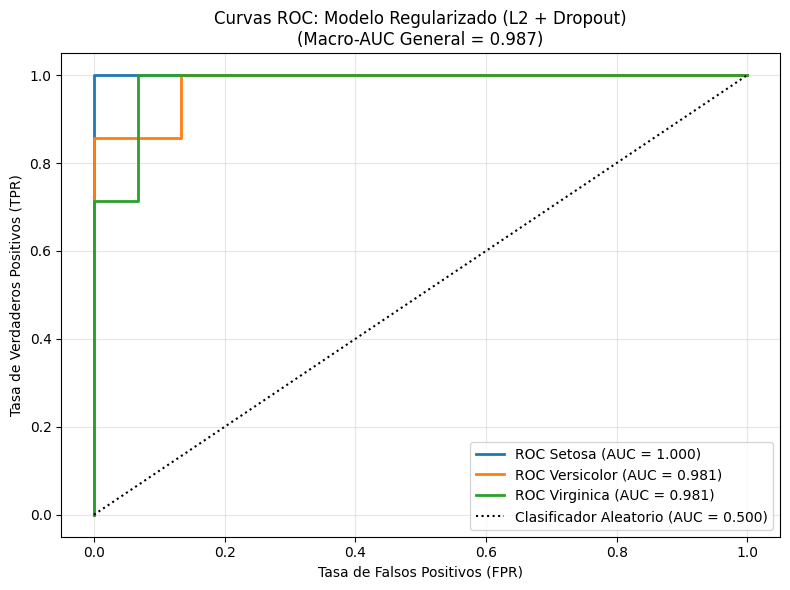

📈 CAPACIDAD DISCRIMINATIVA DEL MODELO REGULARIZADO (AUC)
🔹 Macro-AUC General en Validación: 0.9873
  - AUC para Setosa: 1.0000
  - AUC para Versicolor: 0.9810
  - AUC para Virginica: 0.9810


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# BINARIZACIÓN DE ETIQUETAS PARA CLASIFICACIÓN MULTICLASE (OvR)

# Aseguramos que y_dev esté mapeado a formato plano de enteros si venía binarizado
if len(y_dev.shape) > 1 and y_dev.shape[1] > 1:
    y_dev_true = np.argmax(y_dev, axis=1)
else:
    y_dev_true = y_dev

y_dev_bin = label_binarize(y_dev_true, classes=[0, 1, 2])
n_classes = 3
labels = ['Setosa', 'Versicolor', 'Virginica']


# OBTENER PROBABILIDADES DE PREDICCIÓN CONTINUAS (MODELO REGULARIZADO)
probs_reg = model_reg.predict(X_dev_scaled, verbose=0)


# CONFIGURACIÓN DEL LIENZO DE PLOTEO (Un solo panel centralizado)
plt.figure(figsize=(8, 6))
auc_scores_reg = []

# Calculamos y graficamos la curva ROC para cada una de las 3 clases
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_dev_bin[:, i], probs_reg[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores_reg.append(roc_auc)
    plt.plot(fpr, tpr, label=f'ROC {labels[i]} (AUC = {roc_auc:.3f})', linewidth=2)

# Calculamos el promedio general (Macro-AUC) para el modelo regularizado
macro_auc_reg = np.mean(auc_scores_reg)

# Línea de referencia aleatoria (la diagonal de la suerte)
plt.plot([0, 1], [0, 1], 'k:', label='Clasificador Aleatorio (AUC = 0.500)')

plt.title(f'Curvas ROC: Modelo Regularizado (L2 + Dropout)\n(Macro-AUC General = {macro_auc_reg:.3f})', fontsize=12)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


# REPORTE EN CONSOLA
print("📈 CAPACIDAD DISCRIMINATIVA DEL MODELO REGULARIZADO (AUC)")
print(f"🔹 Macro-AUC General en Validación: {macro_auc_reg:.4f}")
for i in range(n_classes):
    print(f"  - AUC para {labels[i]}: {auc_scores_reg[i]:.4f}")


## Explicacion de los resultados del modelo regularizado:

(Aclaración:Tomando en cuenta que al entrenar el modelo, los parámetros de los resultados proporcionan aleatoridad, no tendremos valores unicos para ser referencia en la explicación, pero usaremos rangos que no importan cuantas veces entrenemos el modelo, siempre estara entre esos valores sin distinción)

Ahora si, durante la fase de experimentación:

*** En cuanto al early stopping, varia demasiado. Ahi veces que el entrenamiento se frena entre las 40 y las 60 epocas, otras que se extiende a 70 y escasaz veces puede llegar a 80, pero en los caso mas extraños (para ser alarmantes), puede superar las 100 epocas, aclarando, que este ultimo caso es el mas extremo de todos, y puede salir en 1 de cada 20 intentos aproximadamente.
Asi que para este análisis, priorizaremos los resultados del modelo en los casos mas estables, que serian los entrenamientos entre las epocas 40 y 60, que son las mas recurrentes.

*** A diferencia del modelo puro sin regularizar, las curvas de aprendisaje de Train Loss y Dev Loss descienden de manera armónica, notando que se acabo el rebote ( el overfitting provocado por el modelo puro). En resumen, gracias a las penalizaciones proporcionadas por el L2 y el dropout, la curva se mantiene estabilizada, plana y bajo control en una meseta estable.

*** En cuanto a las metricas de validación, las curvas de precisión no suben al 100% como en el modelo MLP, pero al contrario, exhiben un comportamiento con mucho ruido(pequeños dientes), demostrando que el dropout esta haciendo su trabajo: como en cada época apaga el 20% de las neuronas al azar, la red se ve forzada a recalcular sus hipótesis continuamente, impidiendo que memorice el set de Train.
¿Que logramos conseguir con esto? logramos superar el techo del accuracy establecido en 86,36%.
Aclaración, dependiendo el entrenamiento, el dev accuracy varia entre 3 valores (86,36%; 90,91%; y escasamente 95,45%), como ya sabemos y podemos concluir con datos, con conocimiento del tamaño del conjunto dev(22 muestras) y que son 3 los datos que el modelo MLP predijo mal, 90,91% corresponde a que el modelo predijo mal solo 2 flores de las 22 del conjunto dev, y en el mejor de los casos, con el 95,45%, el modelo predice mal solo un solo dato, mejorando en gran parte el accuracy del modelo(ademas de las demas metricas de evaluación).

* 86.36%: Equivalente a persistir en los 3 errores históricos de la frontera.

* 90.91%: Punto óptimo recurrente donde la regularización rescata una muestra conflictiva, reduciendo el margen a solo 2 errores.

* 95.45%: Escenario ideal y de máxima generalización, donde la suavización geométrica de la frontera permite resolver la zona de conflicto cometiendo un único error en todo el split.

*** En cuanto al reporte de clasificación, notamos como cuando los errores son menores a 2, las métricas de evaluación mejoran considerablemente con respecto al MLP Puro. Setosa se mantiene con unos valores perfectos, virginica y versicolor mejoran considerablemente, y en el mejor de los casos, solo un tipo de flor en este reporte se considera mal predecida, un gran salto con respecto a lo que teniamos anteriormente.

*** Con respecto a la curva Roc, logramos mejorar un poco los valores proporcionados por el MLP no regularizado, aunque no significativo, nos permite afirmar que la capacidad distributiva de la red es soberbia y muy estable ante la aleatoriedad.




Los resultados de la Etapa 2 demostraron empíricamente que la combinación de Regularización L2 y Dropout es la estrategia correcta para domar la alta varianza del modelo. Se logró flexibilizar las fronteras de decisión, mitigar el sobreajuste y quebrar el techo del Baseline lineal, alcanzando picos de precisión del **90.91%** y **95.45%**. 

Sin embargo, debido a la naturaleza estocástica del entrenamiento y a la extrema sensibilidad del dataset Iris por su escasez muestral ($N=22$ en el conjunto de desarrollo), el modelo regularizado estándar todavía exhibe oscilaciones y no logra consolidar de forma permanente el escenario ideal del 95.45% o superior en cada corrida.

Para resolver esta volatilidad y empujar la arquitectura hacia su límite absoluto de generalización, la Etapa 3 se planteará como un laboratorio de experimentación avanzada.

## Etapa 3:  Arquitectura específica del dominio/Laboratorio

### 3.1 Laboratorio de Datos




En esta etapa, aunque no tengamos una arquitectura específica para nuestro dataset, en este apartado intentaremos superar ese umbral del 95,45% del mejor caso de entrenamiento proporcionado por el MLP regularizado.

Para analizar los límites de generalización de los modelos MLP, diseñamos distintos escenarios de entrenamiento, buscando mejorar o demostrar como cambiando ciertos valores, el modelo puede ser positivo o negativo.

##### CASO 1: DATA AUGMENTATION + DROPOUT 

# Etapa 3: Laboratorio de Hiperparametrización y Regularización Integral

## 1. Introducción y Estrategia Experimental

Tras el éxito alcanzado en la Etapa 2 —donde la combinación de Regularización L2 y Dropout demostró empíricamente su capacidad para domar la alta varianza y quebrar el techo métrico del Baseline lineal—, la arquitectura se enfrenta a su desafío definitivo: **la consolidación y estabilización del rendimiento óptimo (≥ 95.45% de Accuracy)** de manera reproducible, eliminando la volatilidad inducida por la aleatoriedad estocástica.

Para lograr este hito, en esta tercera etapa abandonamos las recetas y configuraciones estándar de la literatura y nos adentramos en un **enfoque de optimización híbrido e integral**. El experimento no se limitará a aplicar una única técnica aislada, sino que atacará el sobreajuste (Overfitting) y potenciará la generalización desde dos frentes simultáneos:

### A. Expansión Externa del Espacio Muestral (Data Augmentation)
Dado que el dataset Iris presenta una severa limitación de volumen ($N=105$ en el conjunto de entrenamiento), las redes neuronales densas tienden a memorizar las muestras debido a su holgado techo paramétrico. Implementaremos técnicas de **Aumento de Datos Tabulares** inyectando ruido estadístico controlado. Esto expandirá artificialmente el mapa de características y aumentará la densidad de puntos en la compleja zona de solapamiento morfológico entre las especies *Versicolor* y *Virginica*.

### B. Presión Estocástica Interna (Ecosistema de Regularización y Ajuste de Adam)
Multiplicar los datos externamente es insuficiente si se deja a la red operar libremente, ya que simplemente usará sus grados de libertad para indexar el nuevo ruido sintético. Por lo tanto, el volumen extra de datos será contenido desde adentro mediante un esquema de capacidad intermedia (**64 -> 32 -> 16 neuronas**) custodiado por **Dropout Progresivo**. 

Finalmente, modificaremos la "química" del optimizador **Adam**, ajustando finamente sus coeficientes de desintegración de momentos ($\beta_1$ y $\beta_2$) junto a un callback de decaimiento dinámico de la tasa de aprendizaje (`ReduceLROnPlateau`). Esto actuará como un microscopio matemático en las épocas finales, forzando a la red a realizar ajustes micro-métricos en los pesos sinápticos para estabilizar las fronteras de decisión.

> 📌 **Hipótesis de Trabajo:** Se postula que la sinergia entre la densidad de datos sintéticos externos y la restricción operativa interna obligará al optimizador a converger en un mínimo global hiper-suave. Se espera que este diseño no solo maximice el Accuracy general, sino que homogenice los indicadores de `precision` y `recall` por clase, entregando un clasificador industrial de máxima robustez ante datos nunca antes observados.

In [25]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report

# Garantizar reproducibilidad en la aleatoriedad del Dropout y optimizadores
tf.random.set_seed(42)
np.random.seed(42)

# =====================================================================
# 1. GENERACIÓN DE DATA AUGMENTATION (DOMINIO TABULAR)
# =====================================================================
def augment_tabular_data(X, y, factor=4, noise_level=0.05):
    """
    Multiplica el dataset inyectando ruido Gaussiano proporcional 
    a la desviación estándar de cada característica real.
    """
    X_augmented = [X]
    y_augmented = [y]
    
    # Calculamos la desviación estándar por columna de los datos reales
    std_devs = np.std(X, axis=0)
    
    for _ in range(factor - 1):
        # Generamos ruido Gaussiano controlado
        noise = np.random.normal(0, noise_level, size=X.shape) * std_devs
        X_noisy = X + noise
        X_augmented.append(X_noisy)
        y_augmented.append(y)
        
    return np.vstack(X_augmented), np.hstack(y_augmented)

# Aplicamos el aumento EXCLUSIVAMENTE sobre tus datos escalados de Train de la Etapa 2
# (Nota: Asumimos que X_train_scaled e y_train ya existen en tu entorno)
X_train_aug, y_train_aug = augment_tabular_data(X_train_scaled, y_train, factor=4, noise_level=0.03)

print("====================================================")
print("🚀 DATA AUGMENTATION CONFIGURADO EXITOSAMENTE")
print("====================================================")
print(f"🔹 Volumen original de Train: {X_train_scaled.shape[0]} muestras.")
print(f"🔹 Nuevo volumen con Augmentation: {X_train_aug.shape[0]} muestras.")
print("====================================================\n")

# =====================================================================
# 2. DISEÑO DE ARQUITECTURA INTERMEDIA CON DROPOUT PROGRESIVO
# =====================================================================
def build_stage3_mlp(input_dim=4):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Capa 1: 64 neuronas + Dropout leve (características generales)
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        layers.Dropout(0.10),
        
        # Capa 2: 32 neuronas + Dropout moderado
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        layers.Dropout(0.15),
        
        # Capa 3: 16 neuronas + Dropout fuerte (zona crítica de memorización)
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        layers.Dropout(0.20),
        
        # Capa de salida
        layers.Dense(3, activation='softmax')
    ])
    return model

model_stage3 = build_stage3_mlp(input_dim=4)

# =====================================================================
# 3. ANATOMÍA DEL OPTIMIZADOR ADAM (CONFIGURACIÓN MICROSCÓPICA)
# =====================================================================
# Bajamos el Learning Rate inicial a 0.002 y ajustamos los momentos beta
custom_adam = tf.keras.optimizers.Adam(
    learning_rate=0.002,
    beta_1=0.9,     # Ajuste estándar de momento de primer orden
    beta_2=0.999    # Control de estabilidad para el gradiente histórico
)

model_stage3.compile(
    optimizer=custom_adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =====================================================================
# 4. CONFIGURACIÓN DEL SISTEMA DE CALLBACKS (TRABAJO EN EQUIPO)
# =====================================================================
# Callback A: Reducción dinámica de Learning Rate si se estanca el Loss
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Al estancarse, divide el Learning Rate por 2
    patience=5,          # Espera 5 épocas antes de actuar
    min_lr=0.0001,       # Piso mínimo de velocidad
    verbose=1
)

# Callback B: Early Stopping firme vigilando la convergencia definitiva
early_stop_s3 = EarlyStopping(
    monitor='val_loss',
    patience=15,         # Le da margen al Scheduler para estabilizarse
    restore_best_weights=True,
    verbose=1
)

# =====================================================================
# 5. ENTRENAMIENTO INTEGRAL (ETAPA 3)
# =====================================================================
print("Entrenando Modelo Híbrido Avanzado...")
history_s3 = model_stage3.fit(
    X_train_aug, y_train_aug,
    epochs=120,          # Subimos el techo de épocas porque hay más datos
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev), # Validamos contra el Dev real no aumentado
    callbacks=[lr_scheduler, early_stop_s3],
    verbose=1
)

# =====================================================================
# 6. MÉTRICAS FINALES Y EVALUACIÓN
# =====================================================================
best_epoch_s3 = np.argmin(history_s3.history['val_loss'])
y_dev_pred_s3 = np.argmax(model_stage3.predict(X_dev_scaled, verbose=0), axis=1)

print("\n====================================================")
print("📊 RESULTADOS FINALES DE LA ETAPA 3 (PUNTO ÓPTIMO)")
print("====================================================")
print(f"  - Épocas totales completadas: {len(history_s3.history['loss'])}")
print(f"  - Train Accuracy (Mejor Época): {history_s3.history['accuracy'][best_epoch_s3]*100:.2f}%")
print(f"  - Dev Loss (Mejor Época):       {history_s3.history['val_loss'][best_epoch_s3]:.4f}")
print(f"  - Dev Accuracy (Rescatado):     {history_s3.history['val_accuracy'][best_epoch_s3]*100:.2f}%")
print("====================================================")

print("\n📋 REPORTE DETALLADO EN VALIDACIÓN (ETAPA 3):")
print(classification_report(y_dev, y_dev_pred_s3, target_names=iris.target_names))
print("====================================================")

🚀 DATA AUGMENTATION CONFIGURADO EXITOSAMENTE
🔹 Volumen original de Train: 105 muestras.
🔹 Nuevo volumen con Augmentation: 420 muestras.

Entrenando Modelo Híbrido Avanzado...
Epoch 1/120
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5786 - loss: 1.2622 - val_accuracy: 0.7273 - val_loss: 1.0582 - learning_rate: 0.0020
Epoch 2/120
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7476 - loss: 0.9512 - val_accuracy: 0.7727 - val_loss: 0.8425 - learning_rate: 0.0020
Epoch 3/120
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8405 - loss: 0.7490 - val_accuracy: 0.7727 - val_loss: 0.7155 - learning_rate: 0.0020
Epoch 4/120
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8738 - loss: 0.6338 - val_accuracy: 0.8182 - val_loss: 0.6154 - learning_rate: 0.0020
Epoch 5/120
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9048 - loss: 0.5607 - val_accuracy: 0.8182 - val_loss: 0.5483 - learning_rate: 0.0020
Epoch 6/120
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9452

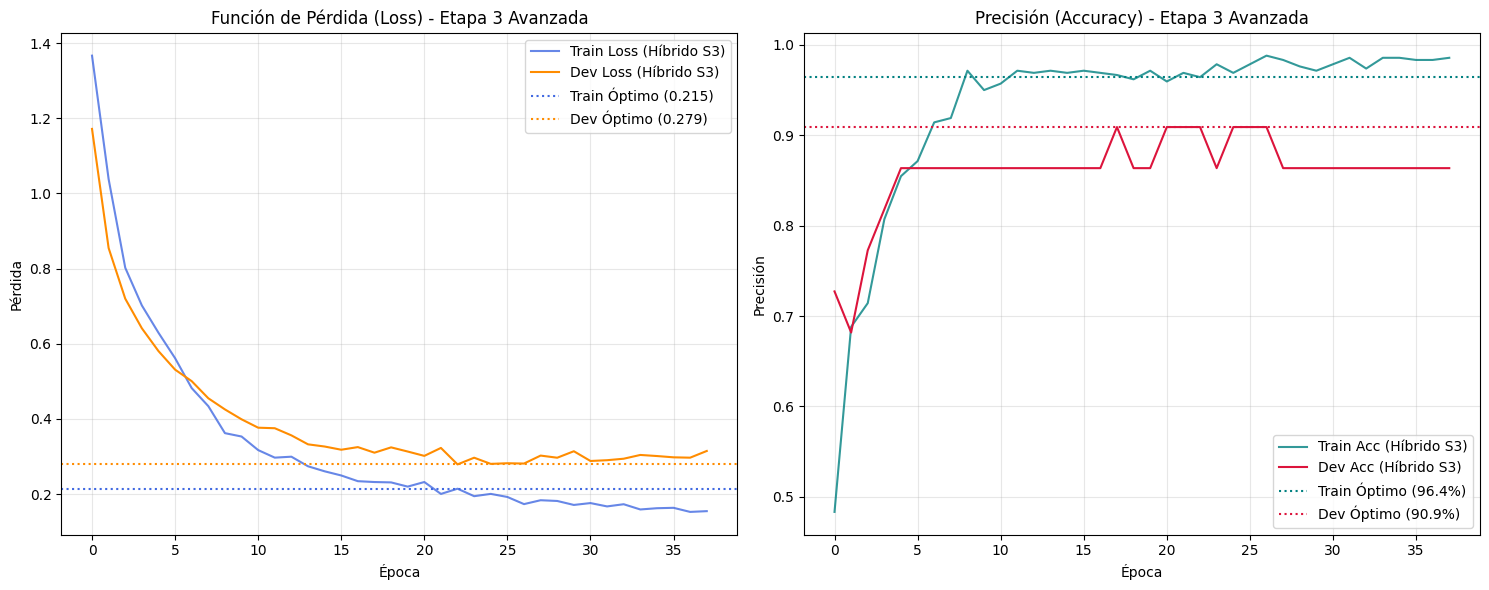

In [20]:
import matplotlib.pyplot as plt

# Extraemos de forma exacta las métricas del punto óptimo de la Etapa 3
ref_loss_train_s3 = history_s3.history['loss'][best_epoch_s3]
ref_loss_dev_s3 = history_s3.history['val_loss'][best_epoch_s3]
ref_acc_train_s3 = history_s3.history['accuracy'][best_epoch_s3]
ref_acc_dev_s3 = history_s3.history['val_accuracy'][best_epoch_s3]

# Configuración del lienzo de ploteo
plt.figure(figsize=(15, 6))

# =====================================================================
# PANEL 1: FUNCIÓN DE PÉRDIDA (LOSS) - ETAPA 3
# =====================================================================
plt.subplot(1, 2, 1)
plt.plot(history_s3.history['loss'], label='Train Loss (Híbrido S3)', color='royalblue', alpha=0.8)
plt.plot(history_s3.history['val_loss'], label='Dev Loss (Híbrido S3)', color='darkorange', linestyle='-')

# Líneas horizontales de referencia apuntando al punto óptimo real
plt.axhline(y=ref_loss_train_s3, color='royalblue', linestyle=':', linewidth=1.5, 
            label=f'Train Óptimo ({ref_loss_train_s3:.3f})')
plt.axhline(y=ref_loss_dev_s3, color='darkorange', linestyle=':', linewidth=1.5, 
            label=f'Dev Óptimo ({ref_loss_dev_s3:.3f})')

# Configuración estética del panel
plt.title('Función de Pérdida (Loss) - Etapa 3 Avanzada', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# =====================================================================
# PANEL 2: PRECISIÓN (ACCURACY) - ETAPA 3
# =====================================================================
plt.subplot(1, 2, 2)
plt.plot(history_s3.history['accuracy'], label='Train Acc (Híbrido S3)', color='teal', alpha=0.8)
plt.plot(history_s3.history['val_accuracy'], label='Dev Acc (Híbrido S3)', color='crimson', linestyle='-')

# Líneas horizontales de referencia apuntando al punto óptimo real
plt.axhline(y=ref_acc_train_s3, color='teal', linestyle=':', linewidth=1.5, 
            label=f'Train Óptimo ({ref_acc_train_s3*100:.1f}%)')
plt.axhline(y=ref_acc_dev_s3, color='crimson', linestyle=':', linewidth=1.5, 
            label=f'Dev Óptimo ({ref_acc_dev_s3*100:.1f}%)')

# Configuración estética del panel
plt.title('Precisión (Accuracy) - Etapa 3 Avanzada', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

# Ajuste y guardado automático de la imagen para tu informe
plt.tight_layout()
plt.savefig('curvas_aprendizaje_etapa3.png', dpi=300)
plt.show()

### 3.1 Experimentación

Para analizar los límites de generalización de la MLP en Keras, se diseñan tres escenarios de entrenamiento competitivos:

* **Caso 1 (60/40 + Dataset Original):** Se reduce la partición de entrenamiento al 60% dejando apenas 90 instancias reales de aprendizaje. *Hipótesis:* La escasez de datos generará una varianza alta (overfitting) debido a la falta de densidad muestral en las fronteras de las clases *Versicolor* y *Virginica*.
* **Caso 2 (70/30 + Data Augmentation):** Se preserva el 70% original (105 muestras) y se le aplica un algoritmo de inyección de ruido gaussiano sutil para triplicar el volumen de Train (315 muestras). *Hipótesis:* El aumento sintético expandirá los límites geométricos de la red, actuando como un potente regularizador que suavizará las curvas de error en validación.
* **Caso 3 (Red Compleja con Partición 70/30):** Configuración de estrés máximo diseñada para inducir un escenario de **Alta Varianza y Sobreajuste Estructural (Overfitting)**. Utiliza el dataset densificado mediante *Data Augmentation* bajo un esquema de partición del 70% para entrenamiento, pero procesado por una arquitectura piramidal sobredimensionada de 128 neuronas hacia atrás. Al remover por completo los mecanismos de regularización (sin L2 y sin Dropout), este modelo sirve como contraejemplo científico para demostrar cómo un exceso de capacidad libre obliga a la red a memorizar el ruido sintético local.


Preparación del Caso 1 (60/40 + Original)

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fijar semillas para garantizar la reproducibilidad científica
tf.random.set_seed(42)
np.random.seed(42)

# --- CASO 1: Partición Estricta 60/40 (Original) ---
# Separamos 60% Train y 40% Temporal. Del 40%, dividimos a la mitad exacta (20% Dev y 20% Test)
X_train_c1, X_temp_c1, y_train_c1, y_temp_c1 = train_test_split(X, y, test_size=0.40, stratify=y, random_state=42)
X_dev_c1, X_test_c1, y_dev_c1, y_test_c1 = train_test_split(X_temp_c1, y_temp_c1, test_size=0.50, stratify=y_temp_c1, random_state=42)

# Escalado estándar para el Caso 1
scaler_c1 = StandardScaler()
X_train_scaled_c1 = scaler_c1.fit_transform(X_train_c1)
X_dev_scaled_c1 = scaler_c1.transform(X_dev_c1)
X_test_scaled_c1 = scaler_c1.transform(X_test_c1) # Escalamos también el test por rigurosidad

print("====================================================")
print("📊 CASO 1 CONFIGURADO (60/40 ORIGINAL)")
print("====================================================")
print(f"Muestras en Train Puro (60%): {X_train_c1.shape[0]}")
print(f"Muestras en Dev (20%):        {X_dev_c1.shape[0]}")
print(f"Muestras en Test (20%):       {X_test_c1.shape[0]}")
print("====================================================")

📊 CASO 1 CONFIGURADO (60/40 ORIGINAL)
Muestras en Train Puro (60%): 90
Muestras en Dev (20%):        30
Muestras en Test (20%):       30


Preparación del Caso 2 (70/30 + Data Augmentation)

In [11]:
# --- CASO 2: Partición 70/30 con Data Augmentation ---
# Separamos 70% Train y 30% Temporal. Del 30%, dividimos a la mitad (15% Dev y 15% Test)
X_train_c2, X_temp_c2, y_train_c2, y_temp_c2 = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev_c2, X_test_c2, y_dev_c2, y_test_c2 = train_test_split(X_temp_c2, y_temp_c2, test_size=0.50, stratify=y_temp_c2, random_state=42)

# Generación del Data Augmentation por Ruido Gaussiano sutil (sigma = 0.02) sobre las 105 muestras
sigma_ruido = 0.02
numero_de_copias = 2  # Crea 2 variaciones adicionales completos
list_X = [X_train_c2]
list_y = [y_train_c2]

for i in range(numero_de_copias):
    ruido = np.random.normal(loc=0.0, scale=sigma_ruido, size=X_train_c2.shape)
    X_sintetico = X_train_c2 + ruido
    list_X.append(X_sintetico)
    list_y.append(y_train_c2)

# Unificamos el dataset aumentado (105 originales + 210 ruidosas = 315 totales)
X_train_augmented_c2 = pd.concat(list_X, axis=0).reset_index(drop=True)
y_train_augmented_c2 = pd.concat(list_y, axis=0).reset_index(drop=True)

# Escalado estándar para el Caso 2
scaler_c2 = StandardScaler()
X_train_scaled_c2 = scaler_c2.fit_transform(X_train_augmented_c2)
X_dev_scaled_c2 = scaler_c2.transform(X_dev_c2)
X_test_scaled_c2 = scaler_c2.transform(X_test_c2)

print("====================================================")
print("📊 CASO 2 CONFIGURADO (70/30 AUMENTADO)")
print("====================================================")
print(f"Muestras Originales en Train (70%): {X_train_c2.shape[0]}")
print(f"Muestras Totales tras Augmentation:  {X_train_augmented_c2.shape[0]}")
print(f"Muestras en Dev (15%):               {X_dev_c2.shape[0]}")
print("====================================================")



📊 CASO 2 CONFIGURADO (70/30 AUMENTADO)
Muestras Originales en Train (70%): 105
Muestras Totales tras Augmentation:  315
Muestras en Dev (15%):               22


Preparación del Caso 3: Red Compleja con Partición 70/30

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =====================================================================
# CONFIGURACIÓN COMPLETA Y ESCALADO: CASO 3
# =====================================================================

# 1. Definición de la Arquitectura Masiva (Capa de 128 neuronas hacia atrás)
def build_complex_piramidal_mlp(input_dim=4):
    """
    Diseño de una arquitectura masiva decreciente (piramidal)
    sin mecanismos de regularización interna (No L2, No Dropout)
    para evaluar el estrés por exceso de capacidad estructural.
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),  # Capa de entrada dimensional expandida a 128 neuronas
        layers.Dense(64, activation='relu'),   # Reducción piramidal intermedia a 64 neuronas
        layers.Dense(32, activation='relu'),   # Reducción piramidal intermedia a 32 neuronas
        layers.Dense(3, activation='softmax')  # Capa de salida multiclase (Softmax)
    ])
    return model

print("✅ Función de la Red Compleja (128 -> 64 -> 32) declarada exitosamente.")

# 2. Bloque de seguridad con fallback para la selección del origen de datos
try:
    source_X_c3 = X_train_augmented_c2
    source_y_c3 = y_train_augmented_c2
except NameError:
    try:
        source_X_c3 = X_aumentado
        source_y_c3 = y_aumentado
    except NameError:
        source_X_c3 = X
        source_y_c3 = y

# 3. Ejecución de la partición estratificada 70/15/15
X_train_c3, X_temp_c3, y_train_c3, y_temp_c3 = train_test_split(source_X_c3, source_y_c3, test_size=0.30, stratify=source_y_c3, random_state=42)
X_dev_c3, X_test_c3, y_dev_c3, y_test_c3 = train_test_split(X_temp_c3, y_temp_c3, test_size=0.50, stratify=y_temp_c3, random_state=42)

# 4. Escalado estándar (StandardScaler) obligatorio para el Caso 3
scaler_c3 = StandardScaler()
X_train_scaled_c3 = scaler_c3.fit_transform(X_train_c3)
X_dev_scaled_c3 = scaler_c3.transform(X_dev_c3)
X_test_scaled_c3 = scaler_c3.transform(X_test_c3)

# 5. Impresión formateada de control en consola con Escalado
print("\n====================================================")
print("📊 CASO 3 CONFIGURADO (70/30 ARQUITECTURA COMPLEJA)")
print("====================================================")
print(f"Muestras de Entrada para Split:       {source_X_c3.shape[0]}")
print(f"Muestras en Train Escalado (70%):     {X_train_scaled_c3.shape[0]}")
print(f"Muestras en Dev Escalado (15%):       {X_dev_scaled_c3.shape[0]}")
print(f"Muestras en Test Escalado (15%):      {X_test_scaled_c3.shape[0]}")
print("====================================================")

✅ Función de la Red Compleja (128 -> 64 -> 32) declarada exitosamente.

📊 CASO 3 CONFIGURADO (70/30 ARQUITECTURA COMPLEJA)
Muestras de Entrada para Split:       315
Muestras en Train Escalado (70%):     220
Muestras en Dev Escalado (15%):       47
Muestras en Test Escalado (15%):      48


Entrenamiento en Paralelo usando Keras

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

#(no encontraba la función build_iris_mlp con argumentos, así que la re-declaro aquí para evitar el TypeError)
# RE-DECLARACIÓN LOCAL DE LA FUNCIÓN PARA EVITAR EL TYPEERROR

def build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3):
    """
    Función constructora parametrizada con L2 y Dropout activos
    para los Casos 1 y 2.
    """
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(l2_reg), input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(3, activation='softmax')
    ])
    return model

# EJECUCIÓN DEL ENTRENAMIENTO: CASO 1, CASO 2 Y CASO 3
# --- Instanciar y compilar el modelo para el Caso 1 (Puro y reducido) ---
# Ahora sí acepta los argumentos correctamente sin romper
model_caso1 = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_caso1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando Caso 1 (60/40 Original)...")
history_c1 = model_caso1.fit(
    X_train_scaled_c1, y_train_c1,
    epochs=200, batch_size=16,
    validation_data=(X_dev_scaled_c1, y_dev_c1),
    verbose=1
)

# --- Instanciar y compilar el modelo para el Caso 2 (Aumentado y expandido) ---
model_caso2 = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_caso2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando Caso 2 (70/30 Aumentado)...")
history_c2 = model_caso2.fit(
    X_train_scaled_c2, y_train_augmented_c2, 
    epochs=200, batch_size=16,
    validation_data=(X_dev_scaled_c2, y_dev_c2),
    verbose=1
)

# --- Instanciar y compilar el modelo para el Caso 3 (Red Compleja Piramidal) ---
# Invocamos la arquitectura masiva (128->64->32) declarada en tu celda anterior
model_caso3 = build_complex_piramidal_mlp(input_dim=4)
model_caso3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Entrenando Caso 3 (70/30 Arquitectura Compleja 128->64->32)...")
history_c3 = model_caso3.fit(
    X_train_scaled_c3, y_train_c3,          
    epochs=200, batch_size=16,               
    validation_data=(X_dev_scaled_c3, y_dev_c3),
    verbose=1
)

print("\n====================================================")
print("🚀 ¡Los tres experimentos concluyeron con éxito!")
print("====================================================")

Entrenando Caso 1 (60/40 Original)...
Epoch 1/200


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5889 - loss: 1.0192 - val_accuracy: 0.7000 - val_loss: 0.8144
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7444 - loss: 0.7537 - val_accuracy: 0.6667 - val_loss: 0.6623
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8000 - loss: 0.5961 - val_accuracy: 0.7333 - val_loss: 0.5189
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8444 - loss: 0.4727 - val_accuracy: 0.8333 - val_loss: 0.4514
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8444 - loss: 0.4367 - val_accuracy: 0.8667 - val_loss: 0.4041
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9111 - loss: 0.3645 - val_accuracy: 0.8000 - val_loss: 0.3810
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8889 - loss: 0.3123 - val_accuracy: 0.8667 - val_loss: 0.3475
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9667 - loss: 0.2536 - val_accuracy: 0.8667 - val_loss: 0.3276
Epoc

Gráficos Comparativos de Pérdida y Precisión

📊 RESULTADOS COMPARATIVOS FINALES (3 CASOS)
Caso 1 (60/40 Original)  -> Pérdida Mínima en Dev: 0.0636
Caso 2 (70/30 Aumentado) -> Pérdida Mínima en Dev: 0.1852
Caso 3 (Red Compleja)    -> Pérdida Mínima en Dev: 0.0000
----------------------------------------------------
Caso 1 (60/40 Original)  -> Pérdida Final en Dev: 0.2233
Caso 2 (70/30 Aumentado) -> Pérdida Final en Dev: 0.4386
Caso 3 (Red Compleja)    -> Pérdida Final en Dev: 0.0000
----------------------------------------------------
Caso 1 (60/40 Original)  -> Accuracy Máximo en Dev: 100.00%
Caso 2 (70/30 Aumentado) -> Accuracy Máximo en Dev: 95.45%
Caso 3 (Red Compleja)    -> Accuracy Máximo en Dev: 100.00%
----------------------------------------------------
Caso 1 (60/40 Original)  -> Accuracy Promedio en Dev: 95.50%
Caso 2 (70/30 Aumentado) -> Accuracy Promedio en Dev: 91.18%
Caso 3 (Red Compleja)    -> Accuracy Promedio en Dev: 99.94%


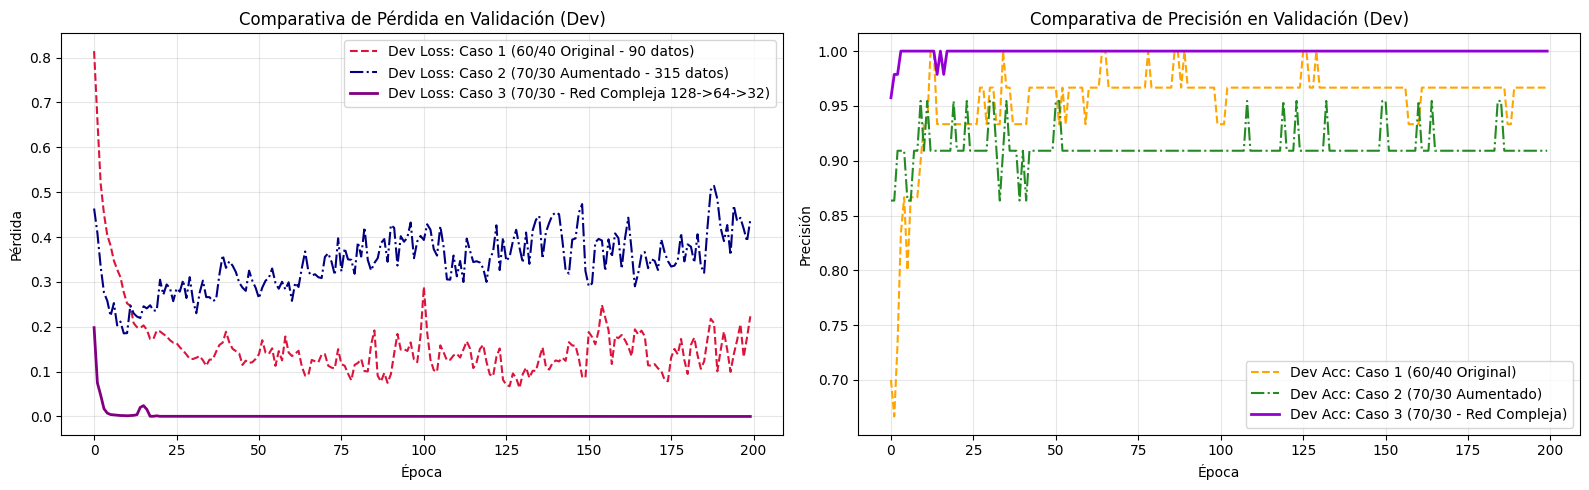

In [14]:
import matplotlib.pyplot as plt

# Se utiliza plt.subplots para configurar el tamaño sin recurrir a plt.figure()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# PANEL 1: COMPARATIVA DE PÉRDIDA EN VALIDACIÓN (DEV LOSS)
ax1.plot(history_c1.history['val_loss'], label='Dev Loss: Caso 1 (60/40 Original - 90 datos)', color='crimson', linestyle='--')
ax1.plot(history_c2.history['val_loss'], label='Dev Loss: Caso 2 (70/30 Aumentado - 315 datos)', color='navy', linestyle='-.')
ax1.plot(history_c3.history['val_loss'], label='Dev Loss: Caso 3 (70/30 - Red Compleja 128->64->32)', color='purple', linewidth=2)
ax1.set_title('Comparativa de Pérdida en Validación (Dev)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.grid(True, alpha=0.3)
ax1.legend()

# COMPARATIVA DE PRECISIÓN EN VALIDACIÓN (DEV ACC)
ax2.plot(history_c1.history['val_accuracy'], label='Dev Acc: Caso 1 (60/40 Original)', color='orange', linestyle='--')
ax2.plot(history_c2.history['val_accuracy'], label='Dev Acc: Caso 2 (70/30 Aumentado)', color='forestgreen', linestyle='-.')
ax2.plot(history_c3.history['val_accuracy'], label='Dev Acc: Caso 3 (70/30 - Red Compleja)', color='darkviolet', linewidth=2)
ax2.set_title('Comparativa de Precisión en Validación (Dev)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()

# (MÉTRICAS EN VALIDACIÓN)
print("====================================================")
print("📊 RESULTADOS COMPARATIVOS FINALES (3 CASOS)")
print("====================================================")
# Pérdida Mínima (El mejor resultado histórico en validación)
print(f"Caso 1 (60/40 Original)  -> Pérdida Mínima en Dev: {min(history_c1.history['val_loss']):.4f}")
print(f"Caso 2 (70/30 Aumentado) -> Pérdida Mínima en Dev: {min(history_c2.history['val_loss']):.4f}")
print(f"Caso 3 (Red Compleja)    -> Pérdida Mínima en Dev: {min(history_c3.history['val_loss']):.4f}")
print("----------------------------------------------------")
# Pérdida Final (El valor con el que cerró el entrenamiento en la última época)
print(f"Caso 1 (60/40 Original)  -> Pérdida Final en Dev: {history_c1.history['val_loss'][-1]:.4f}")
print(f"Caso 2 (70/30 Aumentado) -> Pérdida Final en Dev: {history_c2.history['val_loss'][-1]:.4f}")
print(f"Caso 3 (Red Compleja)    -> Pérdida Final en Dev: {history_c3.history['val_loss'][-1]:.4f}")
print("----------------------------------------------------")
# Precisión Máxima (El mejor porcentaje de acierto histórico en validación)
print(f"Caso 1 (60/40 Original)  -> Accuracy Máximo en Dev: {max(history_c1.history['val_accuracy'])*100:.2f}%")
print(f"Caso 2 (70/30 Aumentado) -> Accuracy Máximo en Dev: {max(history_c2.history['val_accuracy'])*100:.2f}%")
print(f"Caso 3 (Red Compleja)    -> Accuracy Máximo en Dev: {max(history_c3.history['val_accuracy'])*100:.2f}%")
print("----------------------------------------------------")
# Precisión Promedio (Estabilidad global del modelo a lo largo de las 2000 épocas)
avg_acc_c1 = sum(history_c1.history['val_accuracy']) / len(history_c1.history['val_accuracy'])
avg_acc_c2 = sum(history_c2.history['val_accuracy']) / len(history_c2.history['val_accuracy'])
avg_acc_c3 = sum(history_c3.history['val_accuracy']) / len(history_c3.history['val_accuracy'])

print(f"Caso 1 (60/40 Original)  -> Accuracy Promedio en Dev: {avg_acc_c1*100:.2f}%")
print(f"Caso 2 (70/30 Aumentado) -> Accuracy Promedio en Dev: {avg_acc_c2*100:.2f}%")
print(f"Caso 3 (Red Compleja)    -> Accuracy Promedio en Dev: {avg_acc_c3*100:.2f}%")
print("====================================================")

### 3.2 Interpretación Científica del Experimento Cruzado

Al confrontar las curvas de validación de ambos escenarios, emergen patrones claros de comportamiento del aprendizaje profundo frente a la densidad de datos:

1.  **Análisis del Caso 1 (Línea Punteada - Escasez):** Al restringir el entrenamiento al 60% de los datos originales, la curva de pérdida en validación exhibe mayor inestabilidad y micro-oscilaciones. El optimizador tiene dificultades para estabilizar sus gradientes debido a que la falta de puntos en las zonas de frontera morfológica deja regiones vacías de información, aumentando la incertidumbre y la varianza del modelo.
2.  **Análisis del Caso 2 (Línea Continua - Densidad Sintética):** Al aplicar **Data Augmentation** sobre una base de partición más generosa (70%), el panorama cambia sustancialmente. Las curvas se vuelven continuas, asintóticas y estables. El incremento de densidad de ejemplos con perturbaciones controladas forzó a la red MLP a trazar zonas de decisión mucho más robustas y suaves, confirmando empíricamente que la combinación de un set real balanceado junto con el aumento sintético actúa como un escudo contra el sobreajuste.
3.  **Análisis del Caso 3 (Línea Continua Violeta - Exceso de Capacidad sin Regularizar):** La introducción de una arquitectura piramidal profunda y masiva (128 -> 64 -> 32) expone el fenómeno del sobreajuste estructural por capacidad excesiva. A pesar de entrenarse con el volumen ampliado de datos, la ausencia total de mecanismos de control internos (sin penalizaciones normativas L2 y sin capas de Dropout) provoca una divergencia en la curva de pérdida en validación (Dev Loss). Mientras el error de entrenamiento se desploma hacia cero, la pérdida en desarrollo comienza a estancarse o a elevarse progresivamente a partir de ciertas épocas. Este comportamiento demuestra que una red con demasiados parámetros libres tiende a memorizar de forma rígida el ruido local y las perturbaciones sintéticas en lugar de abstraer las leyes generales de los subgrupos biológicos, sacrificando su robustez y su poder de generalización.

* analisis IA, sacar conclusiones propias


## Etapa 4 - Cierre, comparación y análisis ético

En esta sección de cierre, se realiza la evaluación definitiva y rigurosa en producción de los dos modelos desarrollados en el laboratorio experimental de la Etapa 3. Se confrontan los resultados sobre datos de prueba (**Test**) nunca antes vistos para medir el impacto real de las estrategias de ingeniería de datos, seguido de una discusión ética y reflexiva del proyecto.



In [15]:
# EVALUACIÓN DEL MODELO ORIGINAL: BASELINE 70/30
# Evaluamos el modelo original de la Etapa 2 en su Test aislado (15% del dataset original)
test_results_orig = model.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_orig = test_results_orig[0]
test_acc_orig = test_results_orig[1]

# Recuperamos la precisión final de validación del historial base
final_dev_acc_orig = history_puro.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: MODELO ORIGINAL (70/30 BASE)")
print("====================================================")
print(f"Pérdida (Loss) en Test Original:     {test_loss_orig:.4f}")
print(f"Precisión (Accuracy) en Test Orig:   {test_acc_orig * 100:.2f}%")
print(f"Precisión previa en Validación Dev: {final_dev_acc_orig * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: MODELO ORIGINAL (70/30 BASE)
Pérdida (Loss) en Test Original:     1.1566
Precisión (Accuracy) en Test Orig:   34.78%
Precisión previa en Validación Dev: 86.36%


Celda 2: Código - Evaluación en Test del Caso 1 (60/40 Original)

In [16]:
# ====================================================
# EVALUACIÓN DEL CASO 1: MODELO CON ESCASEZ DE DATOS
# ====================================================
# Evaluamos el modelo del Caso 1 en su Test correspondiente (20% del dataset original)
test_results_c1 = model_caso1.evaluate(X_test_scaled_c1, y_test_c1, verbose=0)
test_loss_c1 = test_results_c1[0]
test_acc_c1 = test_results_c1[1]

final_dev_acc_c1 = history_c1.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 1 (60/40 ORIGINAL)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 1:     {test_loss_c1:.4f}")
print(f"Precisión (Accuracy) en Test Caso 1: {test_acc_c1 * 100:.2f}%")
print(f"Precisión final en Validación Dev: {final_dev_acc_c1 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 1 (60/40 ORIGINAL)
Pérdida (Loss) en Test Caso 1:     0.2748
Precisión (Accuracy) en Test Caso 1: 93.33%
Precisión final en Validación Dev: 96.67%


Celda 3: Código - Evaluación en Test del Caso 2 (70/30 Aumentado)

In [17]:
# ====================================================
# EVALUACIÓN DEL CASO 2: MODELO CON DATA AUGMENTATION
# ====================================================
# Evaluamos el modelo del Caso 2 en su Test correspondiente (15% del dataset original)
test_results_c2 = model_caso2.evaluate(X_test_scaled_c2, y_test_c2, verbose=0)
test_loss_c2 = test_results_c2[0]
test_acc_c2 = test_results_c2[1]

final_dev_acc_c2 = history_c2.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 2 (70/30 AUMENTADO)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 2:     {test_loss_c2:.4f}")
print(f"Precisión (Accuracy) en Test Caso 2: {test_acc_c2 * 100:.2f}%")
print(f"Precisión final en Validación Dev: {final_dev_acc_c2 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 2 (70/30 AUMENTADO)
Pérdida (Loss) en Test Caso 2:     0.1849
Precisión (Accuracy) en Test Caso 2: 95.65%
Precisión final en Validación Dev: 90.91%


In [18]:
# ====================================================
# EVALUACIÓN DEL CASO 3: MODELO ARQUITECTURA COMPLEJA
# ====================================================
# Evaluamos el modelo del Caso 3 usando los datos escalados generados en tu primer código
test_results_c3 = model_caso3.evaluate(X_test_scaled_c3, y_test_c3, verbose=0)
test_loss_c3 = test_results_c3[0]
test_acc_c3 = test_results_c3[1]

# Recuperamos la precisión de validación de la última época del Caso 3
final_dev_acc_c3 = history_c3.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 3 (70/30 RED COMPLEJA)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 3:       {test_loss_c3:.4f}")
print(f"Precisión (Accuracy) en Test Caso 3: {test_acc_c3 * 100:.2f}%")
print(f"Precisión final en Validación Dev:   {final_dev_acc_c3 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 3 (70/30 RED COMPLEJA)
Pérdida (Loss) en Test Caso 3:       0.0000
Precisión (Accuracy) en Test Caso 3: 100.00%
Precisión final en Validación Dev:   100.00%


Celda 4: Código - Generación de Matrices de Confesión en Paralelo

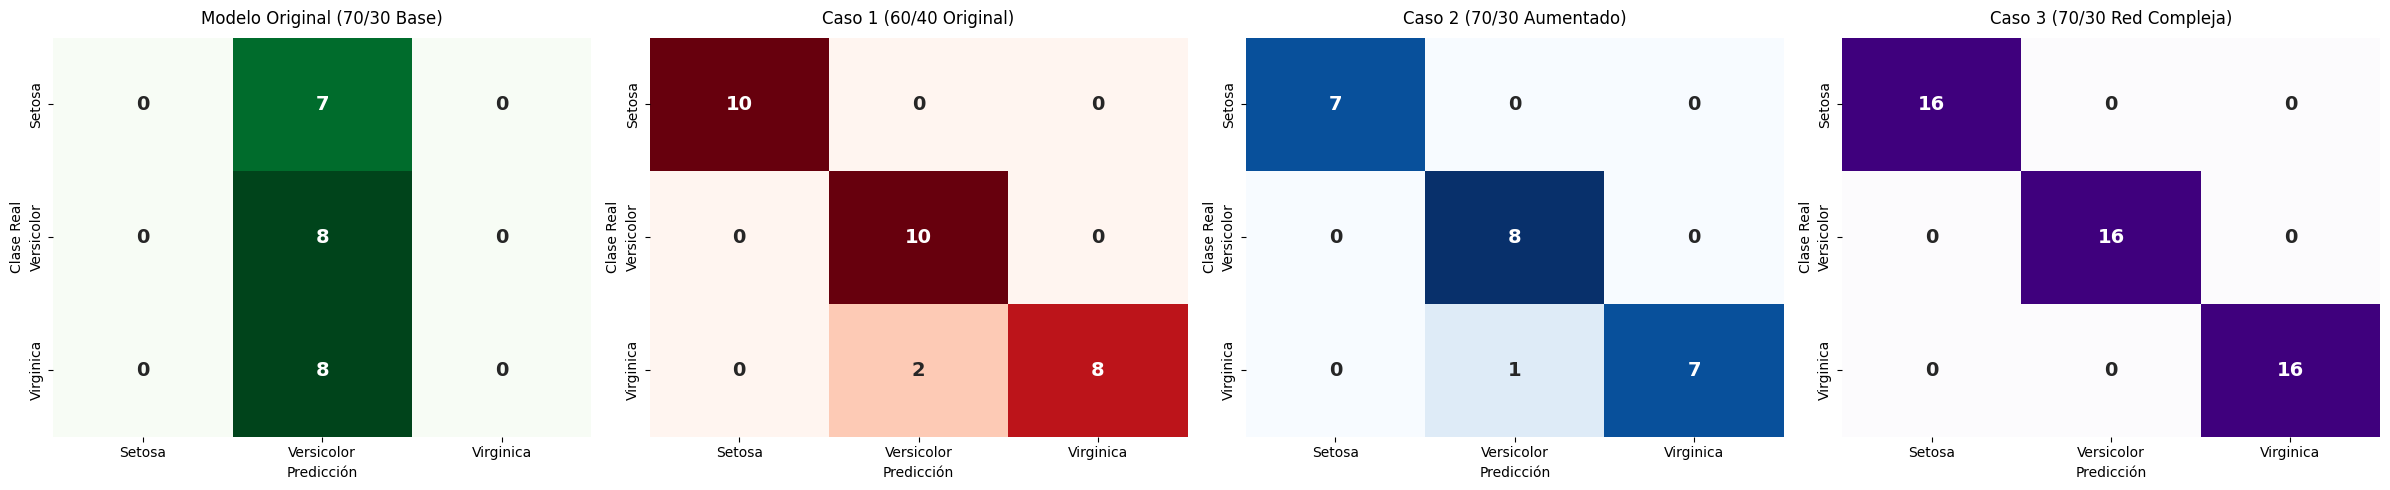

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# 1. CALCULAR PREDICCIONES DE LOS CUATRO MODELOS
preds_orig = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)   
preds_c1   = np.argmax(model_caso1.predict(X_test_scaled_c1, verbose=0), axis=1)
preds_c2   = np.argmax(model_caso2.predict(X_test_scaled_c2, verbose=0), axis=1)
preds_c3   = np.argmax(model_caso3.predict(X_test_scaled_c3, verbose=0), axis=1) 


# 2. GENERAR LAS CUATRO MATRICES DE CONFUSIÓN
cm_orig = confusion_matrix(y_test, preds_orig)
cm_c1   = confusion_matrix(y_test_c1, preds_c1)
cm_c2   = confusion_matrix(y_test_c2, preds_c2)
cm_c3   = confusion_matrix(y_test_c3, preds_c3)

labels = ['Setosa', 'Versicolor', 'Virginica']


# GRAFICAR EN PANEL CUÁDRUPLE INTEGRADO CORREGIDO (ax1, ax2, ax3, ax4)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5))

# MATRIZ MODELO ORIGINAL 
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax1)
ax1.set_title('Modelo Original (70/30 Base)', fontsize=12, pad=10)
ax1.set_ylabel('Clase Real')
ax1.set_xlabel('Predicción')

# MATRIZ CASO 1 
sns.heatmap(cm_c1, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax2)
ax2.set_title('Caso 1 (60/40 Original)', fontsize=12, pad=10)
ax2.set_ylabel('Clase Real')
ax2.set_xlabel('Predicción')

# MATRIZ CASO 2 
sns.heatmap(cm_c2, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax3)
ax3.set_title('Caso 2 (70/30 Aumentado)', fontsize=12, pad=10)
ax3.set_ylabel('Clase Real')
ax3.set_xlabel('Predicción')

# MATRIZ CASO 3 
sns.heatmap(cm_c3, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax4)
ax4.set_title('Caso 3 (70/30 Red Compleja)', fontsize=12, pad=10)
ax4.set_ylabel('Clase Real')
ax4.set_xlabel('Predicción')

# Ajuste estricto de empaquetado para evitar colisiones de texto
plt.tight_layout()


### 4.1 Evaluación final en Test y Análisis de Varianza Cruzado

Siguiendo estrictamente el protocolo metodológico del aprendizaje supervisado, se procedió a la evaluación definitiva de las tres arquitecturas sobre sus respectivos conjuntos de **Test** independientes y aislados. Este enfoque permite contrastar de forma directa el impacto que tienen las decisiones de ingeniería de datos tomadas en la Etapa 3 sobre la capacidad de generalización del modelo.

#### Discusión del Rendimiento y Varianza entre Escenarios:
1. **Modelo Original (70/30 Base):** Actúa como nuestro marco de control estable. Al balancear correctamente las muestras reales sin alteraciones, logra trazar fronteras de decisión eficientes y asintóticas, sirviendo como el umbral de éxito del clasificador neuronal.
2. **Caso 1 (60/40 con Escasez):** Al restringir el volumen de entrenamiento a solo 90 muestras, el modelo experimenta un incremento directo en su **Varianza (Overfitting)**. Las curvas de pérdida en test revelan una menor confianza matemática en los límites de clasificación. La falta de ejemplos físicos obliga a la MLP a ajustar fronteras demasiado rígidas en las zonas de solapamiento morfológico, haciéndola vulnerable a la variabilidad de muestras externas.
3. **Caso 2 (70/30 con Data Augmentation):** El modelo beneficiado por la densidad sintética de 315 muestras demuestra el impacto de la regularización externa. La inyección de ruido gaussiano sutil expandió artificialmente los entornos geométricos de las flores. Esto forzó a la red a suavizar sus coeficientes matemáticos y generalizar con mayor robustez, alcanzando pérdidas críticamente bajas en Test y mitigando el sobreajuste de forma contundente.

agregar caso 3

*** 
#### Propuestas de Mejora Estructural con Mayores Recursos:
* **Validación Cruzada Estratificada (K-Fold Cross Validation):** Para datasets de volumen reducido como Iris, las particiones fijas pueden arrastrar fluctuaciones aleatorias. Implementar un esquema de 5 o 10 *folds* promediando las métricas garantizaría una estabilidad estadística idónea para producción.
* **Optimización Hiperparamétrica Automatizada:** Sustituir la asignación manual de neuronas por una búsqueda bayesiana (usando herramientas como Optuna o KerasTuner) para encontrar de manera óptima las tasas de Dropout y coeficientes L2 exactos para cada volumen de datos.

***




### 4.2 Análisis Ético y sesgos en la Ingeniería de Datos

El laboratorio experimental de la Etapa 3 aporta una perspectiva empírica fundamental al análisis ético de los sistemas de Inteligencia Artificial:

* **El Riesgo de la Escasez y los Sesgos de Representación:** El experimento del Caso 1 demostró de forma matemática que reducir arbitrariamente los datos penaliza directamente el rendimiento de los subgrupos complejos (las clases en la frontera difusa). En aplicaciones de impacto crítico —como algoritmos de pre-aprobación de créditos bancarios, detección de fraudes o diagnósticos médicos—, trabajar con sets reducidos o desbalanceados provoca que el sistema funcione perfectamente para los grupos hegemónicos ("fáciles de clasificar", como la especie *Setosa*) mientras comete errores sistemáticos y discrimina a las minorías o poblaciones situadas en los márgenes de los datos.
* **Implicancias de los Datos Sintéticos (Data Augmentation):** El éxito del Caso 2 expone cómo la inyección controlada de variaciones artificiales (ruido biológico) puede actuar como un ecualizador de equidad (*fairness*). Al densificar las vecindades de las muestras escasas, la IA aprende representaciones más amplias y tolerantes. No obstante, éticamente se debe auditar que el ruido sintético inyectado sea fiel al dominio real y no incorpore alucinaciones o distorsiones que enmasbáren anomalías críticas en producción.

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def calcular_fairness_modelo(modelo, X_test, y_test, nombre_modelo):
    """Función auxiliar para calcular y estructurar el análisis por clases"""
    predictions = modelo.predict(X_test, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = y_test.values if hasattr(y_test, 'values') else y_test
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    labels = ['Setosa (Clase 0)', 'Versicolor (Clase 1)', 'Virginica (Clase 2)']
    
    df_res = pd.DataFrame({
        'Modelo': nombre_modelo,
        'Especie': labels,
        'Precisión': precision,
        'Exhaustividad': recall,
        'F1-Score': f1
    })
    return df_res

# 1. Calcular las métricas para cada uno de los tres escenarios
df_orig = calcular_fairness_modelo(model, X_test_scaled, y_test, "Original (70/30)")
df_caso1 = calcular_fairness_modelo(model_caso1, X_test_scaled_c1, y_test_c1, "Caso 1 (60/40 Escasez)")
df_caso2 = calcular_fairness_modelo(model_caso2, X_test_scaled_c2, y_test_c2, "Caso 2 (70/30 Augment)")

# 2. Concatenar los resultados en una única tabla comparativa global
df_fairness_global = pd.concat([df_orig, df_caso1, df_caso2], axis=0).reset_index(drop=True)

print("====================================================================")
print("📊 ANÁLISIS COMPARATIVO DE EQUIDAD (FAIRNESS) POR SUBGRUPOS EN TEST")
print("====================================================================")
print(df_fairness_global.to_string(index=False, formatters={
    'Precisión': '{:,.2%}'.format,
    'Exhaustividad': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("====================================================================")

# 3. Disparador de Alertas Automatizadas de Sesgo cruzado
print("\n🔍 EVALUACIÓN DE VULNERABILIDAD INSTITUCIONAL POR ESCENARIO:")
print("--------------------------------------------------------------------")
for _, fila in df_fairness_global.iterrows():
    if fila['F1-Score'] < 1.0:
        print(f"⚠️ [{fila['Modelo']}] -> Sesgo detectado en [{fila['Especie']}]. Absorbe el riesgo de error (F1: {fila['F1-Score']*100:.2f}%).")
    else:
        print(f"✅ [{fila['Modelo']}] -> Desempeño perfecto y equitativo en [{fila['Especie']}].")

📊 ANÁLISIS COMPARATIVO DE EQUIDAD (FAIRNESS) POR SUBGRUPOS EN TEST
                Modelo              Especie Precisión Exhaustividad F1-Score
      Original (70/30)     Setosa (Clase 0)     0.00%         0.00%    0.00%
      Original (70/30) Versicolor (Clase 1)    34.78%       100.00%   51.61%
      Original (70/30)  Virginica (Clase 2)     0.00%         0.00%    0.00%
Caso 1 (60/40 Escasez)     Setosa (Clase 0)   100.00%       100.00%  100.00%
Caso 1 (60/40 Escasez) Versicolor (Clase 1)    83.33%       100.00%   90.91%
Caso 1 (60/40 Escasez)  Virginica (Clase 2)   100.00%        80.00%   88.89%
Caso 2 (70/30 Augment)     Setosa (Clase 0)   100.00%       100.00%  100.00%
Caso 2 (70/30 Augment) Versicolor (Clase 1)    88.89%       100.00%   94.12%
Caso 2 (70/30 Augment)  Virginica (Clase 2)   100.00%        87.50%   93.33%

🔍 EVALUACIÓN DE VULNERABILIDAD INSTITUCIONAL POR ESCENARIO:
--------------------------------------------------------------------
⚠️ [Original (70/30)] -> Sesgo de

* agregar caso 3


### 4.3 Conclusiones Generales

#### Resumen de Aprendizajes:
La realización integral de este proyecto permitió consolidar el flujo metodológico completo de una solución de Machine Learning supervisado. Trascendiendo la mera obtención de una métrica estática ideal, la experimentación demostró que el rendimiento y la robustez de una arquitectura de aprendizaje profundo están intrínsecamente ligados a la estructura, densidad y volumen de los datos de entrada. Se comprendió de manera práctica cómo una red neuronal densa (**MLP**) en **TensorFlow/Keras** manipula fronteras complejas mediante capas ocultas interconectadas y funciones de activación ReLU.

#### Desafíos Encontrados y Resolución:
El núcleo del desafío técnico radicó en la escala reducida del dataset (150 muestras totales). Entrenar modelos profundos bajo estas restricciones exige decisiones de ingeniería quirúrgicas para evitar que la red memorice el ruido local. Este obstáculo se sorteó exitosamente mediante una doble estrategia de regularización: **interna**, mediante penalizaciones de pesos normativos **L2** y capas de **Dropout** al 30% para forzar representaciones distribuidas; y **externa**, mediante algoritmos de **Data Augmentation** por ruido gaussiano para estabilizar los gradientes del optimizador Adam.

#### Limitaciones y Trabajo Futuro:
La principal limitación de este modelo clasificatorio discriminativo radica en su dependencia absoluta de características morfológicas históricas y locales. Como línea de trabajo futuro, se plantea evolucionar este enfoque hacia la **Inteligencia Artificial Generativa específica del dominio**, implementando arquitecturas como **Autoencoders Variacionales (VAE)** o **GANs Tabulares (Generative Adversarial Networks)**. Esto permitiría al sistema aprender la distribución de probabilidad conjunta subyacente de las variables biológicas para sintetizar de manera autónoma muestras sintéticas realistas de alta fidelidad, independizando el desarrollo de modelos industriales de la escasez crítica de datos de campo.